# **Capstone Project : Eco-Wise**

## **1. Analisis Permasalahan dan Solusi**

Permasalahan : Pengelolaan sampah yang tidak efisien sering disebabkan oleh kesalahan pemisahan jenis sampah di sumbernya. Hal ini menghambat proses daur ulang karena kontaminasi antar bahan.

Solusi : Membangun model klasifikasi gambar berbasis Deep Learning (MobileNetV2) untuk mengidentifikasi kategori sampah secara otomatis, sehingga dapat diintegrasikan ke dalam sistem tempat sampah pintar atau web pemilihan mandiri.

Dataset yang digunakan merupakan dataset yang terdiri dari 4 kelas utama, yaitu `Anorganik`, `B3`, `Organik`, dan `Non-Waste`. Di dalam setiap kelas, terdapat berbagai jenis material atau kategori limbah yang spesifik, seperti kertas, plastik, dan logam pada kelas `Anorganik`. Baterai dan limbah medis pada kelas `B3`. Serta sisa makanan dan daun kelas `Organik`. Serta object random pada kelas `Non-Waste`.

**Source** : [Trashcan](https://www.kaggle.com/datasets/nathaniae/trashcan-3/data)

## Instal Module

In [ ]:
%pip install tensorflow

In [ ]:
%pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.4/901.4 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

## 1. Gathering Data

**Konfigurasi Awal dan Pemuatan Data**

Pada tahap ini dilakukan persiapan awal yang menjadi fondasi bagi seluruh rangkaian proses. Aktivitas yang dilakukan meliputi pengimporan library yang dibutuhkan, pengaturan variabel global seperti ukuran gambar dan nilai seed untuk menjaga konsistensi hasil, serta menghubungkan notebook dengan Google Drive agar dataset dapat diakses.

### Import Library

In [ ]:
# Library untuk Operasi Dasar dan Pengelolaan File
import os # Digunakan untuk berinteraksi dengan sistem operasi seperti mengatur path dan direktori
import pathlib # Memudahkan pengelolaan path file atau direktori dengan pendekatan berbasis objek
import shutil # Digunakan untuk operasi file tingkat lanjut seperti menyalin atau menghapus folder
import random # Berfungsi untuk menghasilkan nilai acak
import zipfile # Untuk mengelola file berformat ZIP
import glob # Digunakan untuk mencari pola nama file/path secara rekursif (pencarian otomatis folder 'dataset-trashcan')
import json # Digunakan untuk membaca, membuat, atau menyimpan data metadata/data dictionary dalam format JSON

# Library untuk Pengolahan Data dan Komputasi Numerik
import numpy as np # Library utama untuk komputasi numerik, khususnya array multidimensi
import pandas as pd # Digunakan untuk manipulasi dan analisis data dalam bentuk DataFrame
from tqdm.notebook import tqdm as tq  # Menampilkan progress bar interaktif pada notebook (Jupyter/Colab)

# Library Khusus Google Colab
from google.colab import drive # Untuk menghubungkan Google Drive dengan Colab

# Library untuk Visualisasi Data
import matplotlib.pyplot as plt  # Digunakan untuk membuat berbagai jenis visualisasi data
import seaborn as sns  # Library visualisasi berbasis matplotlib dengan tampilan lebih menarik dan statistik

# Library untuk Pengolahan Gambar dan Machine Learning
from PIL import Image  # Digunakan untuk membuka, memproses, dan menyimpan file gambar
from collections import Counter # Untuk menghitung frekuensi kemunculan data dalam list (misalnya channel warna)

# TensorFlow dan Keras (Deep Learning)
import tensorflow as tf  # Framework open-source untuk membangun model machine learning
from tensorflow.keras.applications import MobileNetV2  # Model pre-trained MobileNetV2 untuk transfer learning
from tensorflow.keras import layers, models, callbacks, optimizers  # Komponen utama Keras:
                                                                    # layers: penyusun layer model (Dense, Conv2D, dll.)
                                                                    # models: untuk membangun model (Sequential/Functional)
                                                                    # callbacks: fungsi tambahan saat training (EarlyStopping, dll.)                                                                # optimizers: algoritma optimasi (Adam, SGD, dll.)
from tensorflow.keras.regularizers import l2  # Digunakan untuk regularisasi L2 guna mencegah overfitting
from tensorflow.keras.preprocessing import image # Utilitas preprocessing gambar sebelum masuk ke model

# Scikit-learn (Pendukung Machine Learning)
from sklearn.model_selection import train_test_split  # Untuk membagi data menjadi train dan test/validasi
from sklearn.utils import class_weight  # Menghitung bobot kelas untuk dataset yang tidak seimbang
from sklearn.metrics import confusion_matrix, classification_report  # Evaluasi performa model klasifikasi

# MLflow (Manajemen Eksperimen ML)
import mlflow  # Platform untuk mengelola dan melacak eksperimen machine learning
import mlflow.tensorflow  # Integrasi MLflow dengan TensorFlow/Keras
# --- Library Tambahan ---
import tempfile  # Digunakan untuk membuat file atau folder sementara

# Menghilangkan Warning agar output lebih bersih
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

### Konfigurasi Dasar dan Pemuatan Data Awal

In [ ]:
# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Untuk menyesuaikan path dataset yang tersimpan dalam file .zip di Google Drive, terdapat dua langkah utama yang perlu dilakukan, yaitu menghubungkan (mount) Google Drive ke Colab, kemudian mengekstrak file tersebut agar gambar di dalamnya dapat diakses dan dibaca oleh skrip Python.

### 1.1 Konfigurasi Dasar

In [ ]:
# Konfigurasi Dasar
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

### 1.2 Data Loading

In [ ]:
# Path ke folder dataset di Google Drive
drive_path = '/content/drive/MyDrive/'
project_folder = 'ecowise'  # Nama folder proyek di Drive
dataset_name_zip = 'ecowise_dataset.zip'  # Nama file zip
extracted_dataset_folder_name = 'dataset-trashcan'  # Nama folder setelah diekstrak

dataset_base_path = os.path.join(drive_path, project_folder)
zip_file_path = os.path.join(dataset_base_path, dataset_name_zip)
dataset_dir = os.path.join(dataset_base_path, extracted_dataset_folder_name)
base_path_split = os.path.join(dataset_base_path, 'split_data')

Selanjutnya, dataset akan diekstrak dari file berformat .zip (jika diperlukan), kemudian dilakukan pengumpulan path seluruh file gambar secara terstruktur. Informasi tersebut, bersama dengan label awal yang diperoleh dari struktur folder, akan disusun ke dalam DataFrame menggunakan Pandas. DataFrame ini nantinya akan digunakan sebagai landasan untuk proses eksplorasi data pada tahap berikutnya

In [ ]:
if not os.path.exists(dataset_dir):
    print(f"Mengekstrak: '{zip_file_path}' ke '{dataset_base_path}'")
    if os.path.exists(zip_file_path):
        get_ipython().system('unzip -q "{zip_file_path}" -d "{dataset_base_path}"')
        print(f"File '{dataset_name_zip}' berhasil diekstrak ke: {dataset_base_path}")
    else:
        print(f"File ZIP '{dataset_name_zip}' tidak ditemukan di: {zip_file_path}")
else:
    print(f"Folder dataset '{dataset_dir}' sudah ada.")

Folder dataset '/content/drive/MyDrive/ecowise/dataset-trashcan' sudah ada.


### 1.3 Mengumpulkan Path Gambar dan Label Awal untuk EDA

In [18]:
all_file_paths_eda = []
all_labels_initial_eda = []
all_labels_main_eda = []
image_modes_eda = []
image_sizes_eda = {}

# Untuk dataset ecowise dengan subfolder di dalam setiap kelas
# Struktur: dataset_dir/kelas/subfolder/gambar.jpg
categories = ['Anorganik', 'B3', 'Organik', 'Non-Waste']

for category in categories:
    image_sizes_eda[category] = []
    category_path = os.path.join(dataset_dir, category)

    if os.path.exists(category_path) and os.path.isdir(category_path):
        # Loop melalui semua subfolder di dalam category
        for subfolder in os.listdir(category_path):
            subfolder_path = os.path.join(category_path, subfolder)
            if os.path.isdir(subfolder_path):
                for filename in os.listdir(subfolder_path):
                    if filename.lower().endswith(('.png', '.jpg', '.jpeg')) and not filename.startswith('.'):
                        img_path = os.path.join(subfolder_path, filename)
                        all_file_paths_eda.append(img_path)
                        all_labels_initial_eda.append(f"{category} ({subfolder})")
                        all_labels_main_eda.append(category)
                        try:
                            with Image.open(img_path) as img:
                                image_modes_eda.append(img.mode)
                                image_sizes_eda[category].append(img.size)
                        except Exception as e:
                            print(f"Gagal membaca info gambar {img_path}: {e}")
    else:
        print(f"Folder tidak ditemukan atau bukan direktori: {category_path}")

if not all_file_paths_eda:
    raise ValueError("Tidak ada file gambar yang ditemukan untuk EDA. Periksa path dataset_dir dan struktur folder.")

df_eda = pd.DataFrame({
    "path": all_file_paths_eda,
    "labels_initial": all_labels_initial_eda,
    "labels_main": all_labels_main_eda
})
print(f"Total gambar ditemukan untuk EDA: {len(df_eda)}")

Total gambar ditemukan untuk EDA: 17620


Semua path file gambar bersama dengan label utama (Anorganik, Organik, B3, dan Non-Waste) dan label yang lebih detail telah dikumpulkan dan diorganisir ke dalam DataFrame, yang berisi total 17.620 gambar.

## 2. Assesing Data

### 2.1 Informasi Dataset

In [ ]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17620 entries, 0 to 17619
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   path            17620 non-null  object
 1   labels_initial  17620 non-null  object
 2   labels_main     17620 non-null  object
dtypes: object(3)
memory usage: 413.1+ KB


DataFrame berisi 17.620 baris dan memiliki 3 kolom. Semua kolom bertipe data `object`.

### 2.2 Missing Values

In [ ]:
df_eda.isna().sum()

,0
path,0
labels_initial,0
labels_main,0


Semua kolom pada dataframe tidak memiliki nilai yang hilang atau missing values. Setiap kolom menunjukkan angka 0, yang berarti tidak ada baris kosong atau NaN di dalamnya. Setiap entri dalam dataframe lengkap, tidak ada informasi yang kosong atau tidak tercatat. Hal ini penting untuk memastikan bahwa analisis yang dilakukan akan berdasarkan data yang utuh. Kemudian tidak perlu melakukan penganganan missing values. Dengan tidak adanya nilai yang hilang, model atau algoritma yang akan dibangun tidak akan terpengaruh oleh celah data, yang berpotensi menghasilkan hasil analisis atau prediksi yang lebih akurat dan dapat diandalkan.

### 2.3 Duplikasi Data

In [ ]:
print("Jumlah Duplikasi :", df_eda.duplicated().sum())

Jumlah Duplikasi : 0


Tidak terdapat baris yang terduplikasi secara identik dalam dataframe. Ketidaan duplikasi menjamin bahwa setiap baris dalam dataset adalah unik. Hal ini sangat penting untuk menjaga integritas dan keandalan data, memastikan bahwa setiap entri merepresentasikan informasi yang berbeda dan bukan pengulangan yang tidak perlu. Data duplikat dapat menyebabkan bias dalam analisis statistik dan pelatihan model. Misalnya, jika ada gambar yang dihitung dua kali, model mungkin akan terlalu sering melihat gambar tersebut dan menganggapnya lebih penting, sehingga mengurangi kemampuan generalisasinya. Dengan tidak adanya duplikasi, setiap data akan memiliki bobot yang setara, menghasilkan analisis yang objektif.  

### 2.4 Deskripsi Data

In [ ]:
df_eda.describe()

,path,labels_initial,labels_main
count,17620,17620,17620
unique,17620,20,4
top,/content/drive/MyDrive/EcoWise/dataset-trashca...,Non-Waste (random_objects),Anorganik
freq,1,1649,6471



1.  Kolom `path` bersifat unik untuk setip baris, menunjukkan setiap entri merepresentasikan gambar yang berbeda.

*   `count` : Terdapat 17.620 entri, yang menunjukkan jumlah total gambar yang diproses.
*   `unique` : Jumlah nilai unik adalah 17.620 yang berarti setiap gambar memiliki jalur file yang berbeda dan unik. Ini  membuktikan tidak adanya duplikasi file gambar berdasarkan jalur, menjaga integritas setiap entri data.
*   `top` : Menunjukkan jalur file yang paling sering muncul.
*   `freq` : Frekuensi dari `top` adalah 1, membuktikan bahwa setiap jalur file hanya muncul satu kali.
*   Insight : Kolom `path` adalah pengidentifikasi untuk untuk setiap gambar. Setiap baris dalam DataFrame merepresentasikan gambar yang berbeda, yang sangat penting untuk dianalisis dan pelatihan model yang tidak bias.

2.  Kolom `labels_initial` memiliki 20 kategori unik (`Anorganik(PET)`, `Organik(kertas)`).
*   `count` : Sama dengan total entri 17.620, menandakan tidak ada nilai yang hilang.
*   `unique` : Terdapat 20 kategori unik. Ini menunjukkan bahwa dataset memiliki tingkat granulitas yang cukup tinggi, membagi sampah ke dalam 20 jenis material atau kondisi yang berbeda.
*   `top` : Kategori yang paling sering muncukl adalah `Non-Waste`
*   `freq` : Kategori `Non-Waste` muncul sebanyak 1.649 kali.
*   Insight : Dataset tersebut memiliki 20 sub-kategori sampah, memberikan potensi untuk model klasifikasi yang sangat spesifik. Namun, dominasi `Non-Waste` dengan 1.649 gambar.

3. Kolom `labels_main` memiliki kategori unik 4 yaitu `Anorganik`, `B3`, `Organik`, dan `Non-Waste`.
*   `count` : Terdapat 17.620 entri.
*   `unique` : Hanya ada 4 kategori unik, yaitu `Anorganik`, `B3`, `Organik`, dan `Non-Waste`. Ini adalah level klasifikasi utama yang lebih umum.
*   `top` : Kategori utama yang paling sering muncul adalah `Anorganik`.
*   `freq` : Kategori `Anorganik` muncul sebanyak 6.471.
*   Insight : Data dikelompokkan ke dalam 4 kategori utama. Kategori `Anorganik` adalah yang paling dominan, diikuti oleh `Organik`, `B3`, dan `Non-Waste`. Informasi ini krusial untuk memahami distribusi kelas pada tingkat makro dan mengidentifikasi potensi ketidakseimbangan kelas pada kategori utama, yang dapat mempengaruhi performa model.

### 2.5 Cek Data Corrupt / Error Image

In [ ]:
corrupt = 0

# Memastikan DATASET_PATH dan classes terdefinisi untuk sel ini
DATASET_PATH = "/content/drive/MyDrive/ecowise/split_data/train"
# Periksa apakah path ada sebelum mencoba os.listdir
if not os.path.exists(DATASET_PATH):
    print(f"Error: Path '{DATASET_PATH}' tidak ditemukan. Pastikan data split sudah dibuat.")
    classes = []
else:
    classes = os.listdir(DATASET_PATH)

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    # Pastikan cls_path adalah direktori sebelum mencoba os.listdir
    if os.path.isdir(cls_path):
        for img_name in os.listdir(cls_path):
            try:
                img = Image.open(os.path.join(cls_path, img_name))
                img.verify()
            except:
                corrupt += 1
    else:
        print(f"Peringatan: '{cls_path}' bukan direktori atau tidak ada.")

print("Jumlah gambar corrupt:", corrupt)

Error: Path '/content/drive/MyDrive/ecowise/split_data/train' tidak ditemukan. Pastikan data split sudah dibuat.
Jumlah gambar corrupt: 0


Berdasarkan hasil pengecekan, tidak ada gambar yang rusak atau 'corrupt' yang ditemukan dalam dataset. Ini merupakan indikator positif yang sangat penting, karena menjamin kualitas data yang tinggi. Dengan tidak adanya gambar yang rusak, kita dapat memastikan bahwa:

1.  **Integritas Data Terjaga**: Setiap gambar dalam dataset dapat dibaca dan diproses dengan benar oleh model, tanpa risiko error atau kegagalan pemrosesan.
2.  **Efisiensi Pelatihan Model**: Proses pelatihan model akan berjalan lebih lancar dan efisien, karena tidak ada waktu yang terbuang untuk menangani gambar yang tidak valid.
3.  **Kualitas Model Lebih Baik**: Model dapat belajar dari semua data yang tersedia secara maksimal, yang berkontribusi pada generalisasi yang lebih baik dan performa yang lebih akurat dalam mengidentifikasi berbagai kategori sampah. Data yang bersih adalah fondasi untuk model yang robust dan handal.

## 3. Cleanning Data

### 3.1 Menangani Missing Values

In [19]:
# Isi missing values di 'labels_main' dengan nilai yang paling sering muncul (modus)
df_eda['labels_main'].fillna(df_eda['labels_main'].mode()[0], inplace=True)

# Isi missing values di 'labels_initial' dengan nilai 'Unknown' atau modus
df_eda['labels_initial'].fillna('Unknown', inplace=True)

print("Missing Values setelah penanganan:")
print(df_eda.isna().sum())

Missing Values setelah penanganan:
path              0
labels_initial    0
labels_main       0
dtype: int64


### 3.2 Menangani Duplikasi Data

In [20]:
# Hapus baris duplikat
df_eda.drop_duplicates(inplace=True)

print("Jumlah Duplikasi setelah penanganan:")
print(df_eda.duplicated().sum())

Jumlah Duplikasi setelah penanganan:
0


### 3.3 Menangani Inkosisten Label

In [21]:
# Konversi semua label di 'labels_main' ke format standar (misalnya, judul)
df_eda['labels_main'] = df_eda['labels_main'].apply(lambda x: x.title() if isinstance(x, str) else x)

print("Distribusi unik 'labels_main' setelah penanganan inkonsistensi:")
print(df_eda['labels_main'].value_counts(dropna=False))

Distribusi unik 'labels_main' setelah penanganan inkonsistensi:
labels_main
Anorganik    6471
Organik      6000
B3           3500
Non-Waste    1649
Name: count, dtype: int64


### Insight dari Proses Cleaning Data

Proses cleaning data yang telah dilakukan mencakup penanganan *missing values*, penghapusan data duplikasi, dan standardisasi label. Hasil dari langkah-langkah ini menunjukkan bahwa data telah berhasil dibersihkan dan diorganisir dengan baik, yang merupakan fondasi krusial untuk analisis dan pengembangan model yang akurat.

1.  **Penanganan Missing Values**: Tidak ditemukan adanya *missing values* di kolom `path`, `labels_initial`, maupun `labels_main`. Ini mengindikasikan bahwa dataset sangat bersih dan lengkap dari awal, sehingga tidak ada informasi yang hilang yang dapat mengganggu proses selanjutnya. Kondisi ini mempercepat tahap *data preprocessing* dan menjamin bahwa setiap entri data memiliki informasi yang utuh.

2.  **Penanganan Duplikasi Data**: Pengecekan duplikasi menunjukkan bahwa tidak ada baris yang terduplikasi secara identik. Ini memastikan setiap data unik dan representatif, mencegah bias dalam analisis statistik dan pelatihan model. Jika ada duplikasi, model mungkin akan terlalu sering melihat gambar yang sama, sehingga mengurangi kemampuannya untuk menggeneralisasi ke data baru. Dengan data yang bebas duplikasi, model dapat belajar dari keragaman data yang sebenarnya.

3.  **Standardisasi Label**: Label-label pada kolom `labels_main` telah distandardisasi ke format 'Title Case' (misalnya, 'Anorganik', 'Organik', 'B3', 'Non-Waste'). Standardisasi ini sangat penting untuk menjaga konsistensi dalam representasi kelas, yang mempermudah proses pengelompokan, analisis, dan terutama saat membangun model klasifikasi. Label yang konsisten menghindari potensi kesalahan interpretasi oleh model dan memastikan bahwa setiap kategori diidentifikasi secara seragam. Distribusi kelas setelah standardisasi menunjukkan:
    *   `Anorganik`: 6471 gambar
    *   `Organik`: 6000 gambar
    *   `B3`: 3500 gambar
    *   `Non-Waste`: 1649 gambar

Secara keseluruhan, proses cleaning data ini berhasil menghasilkan dataset yang rapi, konsisten, dan siap untuk tahap analisis eksplorasi data (EDA) yang lebih mendalam dan persiapan untuk pembangunan model. Kualitas data yang tinggi pada tahap awal akan berdampak positif pada performa dan keandalan model akhir.

## 4. Pertanyaan Bisnis


1.   Bagaimana dominasi kategori limbah dalam dataset?
2.   Jenis material apa yang paling mendominasi di setiap kategori?
3.   Apa saja isi dari kategori B3 atau Anorganik secara spesifik?

## 5. Exploratory Data Analysis (EDA)

### 5.1 Sampel Gambar untuk Semua Kelas dan Jenis

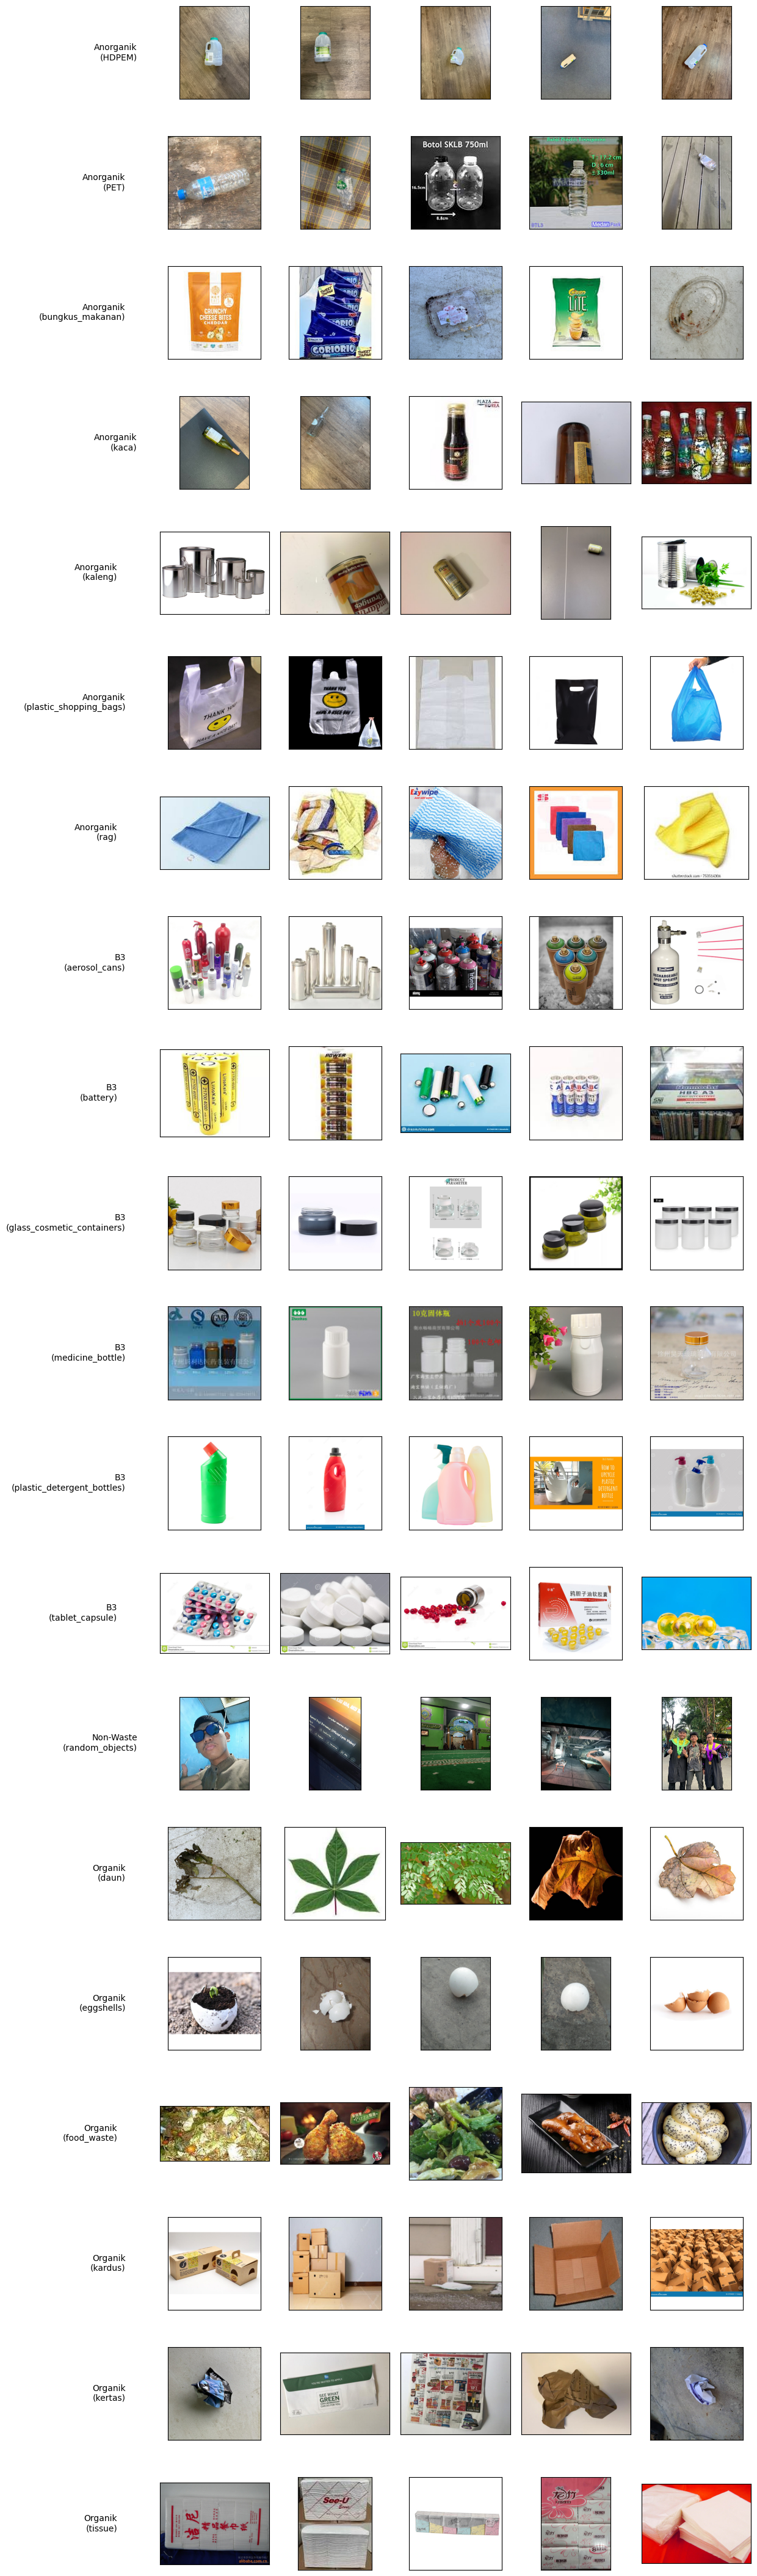

In [22]:
num_samples_to_display = 5
all_images_by_category_plot = {}

categories = ['Anorganik', 'B3', 'Organik', 'Non-Waste']

for category in categories:
    category_path = os.path.join(dataset_dir, category)
    if os.path.exists(category_path) and os.path.isdir(category_path):
        # Loop melalui semua subfolder di dalam category
        for sub_folder in os.listdir(category_path):
            sub_folder_path = os.path.join(category_path, sub_folder)
            if os.path.isdir(sub_folder_path):
                # Cari file gambar di dalam subfolder
                image_files = [
                    f for f in os.listdir(sub_folder_path)
                    if os.path.isfile(os.path.join(sub_folder_path, f)) and
                    f.lower().endswith(('.png', '.jpg', '.jpeg'))
                ]
                if image_files:
                    # Key name menampilkan kelas dan subfolder
                    key_name = f"{category}\n({sub_folder})"
                    all_images_by_category_plot[key_name] = [
                        os.path.join(sub_folder_path, fname) for fname in image_files
                    ]

# Urutkan berdasarkan nama kategori untuk konsistensi
sorted_categories_plot = sorted(all_images_by_category_plot.keys())
num_categories_to_plot = len(sorted_categories_plot)

if num_categories_to_plot > 0:
    # Setup subplots
    fig, axs = plt.subplots(num_categories_to_plot, num_samples_to_display,
                            figsize=(num_samples_to_display * 2.5, num_categories_to_plot * 2.5))

    # Handle kasus dimensi axes yang berbeda
    if num_categories_to_plot == 1:
        axs = np.array([axs])
    if num_samples_to_display == 1 and num_categories_to_plot > 1:
        axs = axs.reshape(-1, 1)
    elif num_samples_to_display == 1 and num_categories_to_plot == 1:
        axs = np.array([[axs]])

    for i, category_name in enumerate(sorted_categories_plot):
        image_paths_list = all_images_by_category_plot[category_name]

        if image_paths_list:
            # Pilih sampel gambar secara acak
            selected_image_paths = np.random.choice(
                image_paths_list,
                min(num_samples_to_display, len(image_paths_list)),
                replace=False
            )

            # Set label untuk baris ini (hanya di kolom pertama)
            if num_samples_to_display > 0:
                axs[i, 0].set_ylabel(
                    category_name,
                    rotation=0,
                    size='medium',
                    labelpad=50,
                    ha='right',
                    va='center'
                )

            # Tampilkan gambar di setiap kolom
            for j in range(num_samples_to_display):
                if j < len(selected_image_paths):
                    img_path_plot = selected_image_paths[j]
                    try:
                        img_plot = Image.open(img_path_plot).convert('RGB')
                        axs[i, j].imshow(img_plot)
                    except Exception:
                        axs[i, j].set_title("Error", fontsize=8)
                else:
                    axs[i, j].text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=10)

                axs[i, j].set_xticks([])
                axs[i, j].set_yticks([])
                axs[i, j].set_xlabel('')
        else:
            # Jika tidak ada gambar di kategori ini
            if num_samples_to_display > 0:
                axs[i, 0].set_ylabel(
                    category_name,
                    rotation=0,
                    size='medium',
                    labelpad=50,
                    ha='right',
                    va='center'
                )
            for j in range(num_samples_to_display):
                axs[i, j].text(0.5, 0.5, 'No Images', ha='center', va='center', fontsize=10)
                axs[i, j].set_xticks([])
                axs[i, j].set_yticks([])
                axs[i, j].set_xlabel('')

    plt.subplots_adjust(hspace=0.4, wspace=0.1, top=0.95)
    plt.show()
else:
    print("Tidak ada data gambar untuk sampel EDA.")

Berdasarkan visualisasi sampel gambar, dapat dilihat bahwa dataset memiliki variasi yang cukup baik dalam hal jenis objek, latar belakang, pencahayaan, dan sudut pengambilan gambar di setiap kategori.

Variasi ini menunjukkan bahwa dataset memiliki kompleksitas yang cukup tinggi, sehingga model yang digunakan harus mampu melakukan generalisasi dengan baik terhadap berbagai kondisi citra.

### 5.2 Distribusi Gambar per Kelas Utama (Anorganik vs B3 vs Organik vs Non-Waste)

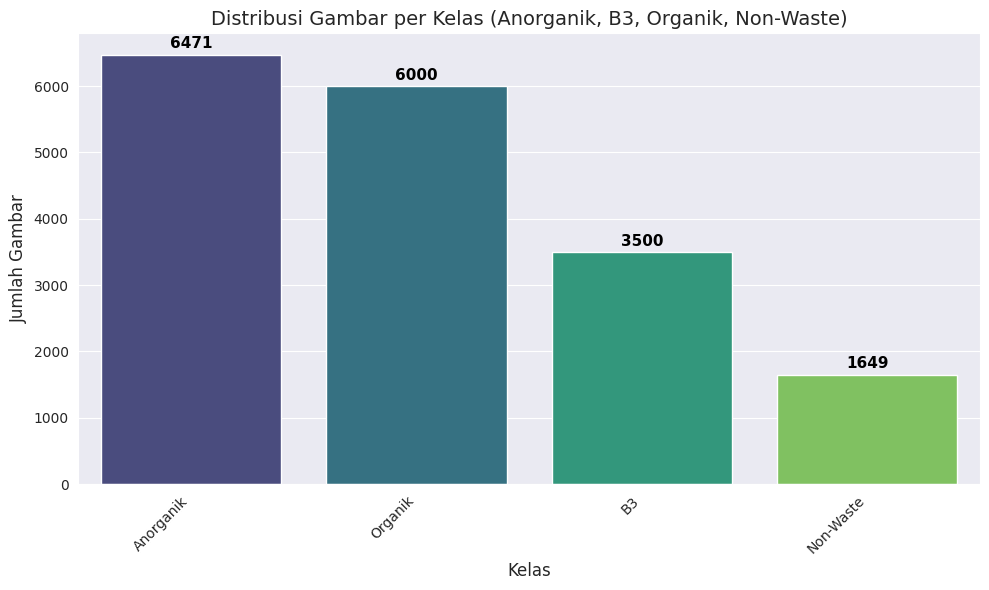


Jumlah Gambar per Kelas (Anorganik, B3, Organik, Non-Waste):
  Anorganik: 6471 gambar
  Organik: 6000 gambar
  B3: 3500 gambar
  Non-Waste: 1649 gambar


In [23]:
label_counts_main_eda = df_eda['labels_main'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
ax = sns.countplot(x='labels_main', data=df_eda, order=label_counts_main_eda.index, palette="viridis")

# Judul disesuaikan
plt.title('Distribusi Gambar per Kelas (Anorganik, B3, Organik, Non-Waste)', fontsize=14)
plt.xlabel('Kelas', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)

# Tambahkan label jumlah di atas bar
for i, v in enumerate(label_counts_main_eda.values):
    ax.text(i, v + 50, str(v), color='black', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

print("\nJumlah Gambar per Kelas (Anorganik, B3, Organik, Non-Waste):")
for kelas, jumlah in label_counts_main_eda.items():
    print(f"  {kelas}: {jumlah} gambar")

1. Dominasi Kategori: Kategori 'Anorganik' dan 'Organik' adalah yang paling dominan dalam dataset, dengan 'Anorganik' sedikit lebih banyak (6.471 gambar) diikuti oleh 'Organik' (6.000 gambar).
2. Ketidakseimbangan Kelas: Terdapat ketidakseimbangan yang signifikan antar kelas. Kategori 'Non-Waste' memiliki jumlah gambar yang paling sedikit (1.649 gambar), menjadikannya kelas minoritas dibandingkan dengan kategori 'Anorganik' dan 'Organik' yang jauh lebih banyak. Kategori 'B3' juga tergolong minoritas dengan 3.500 gambar.

### 5.3 Distribusi Gambar per Kelas dan Jenis

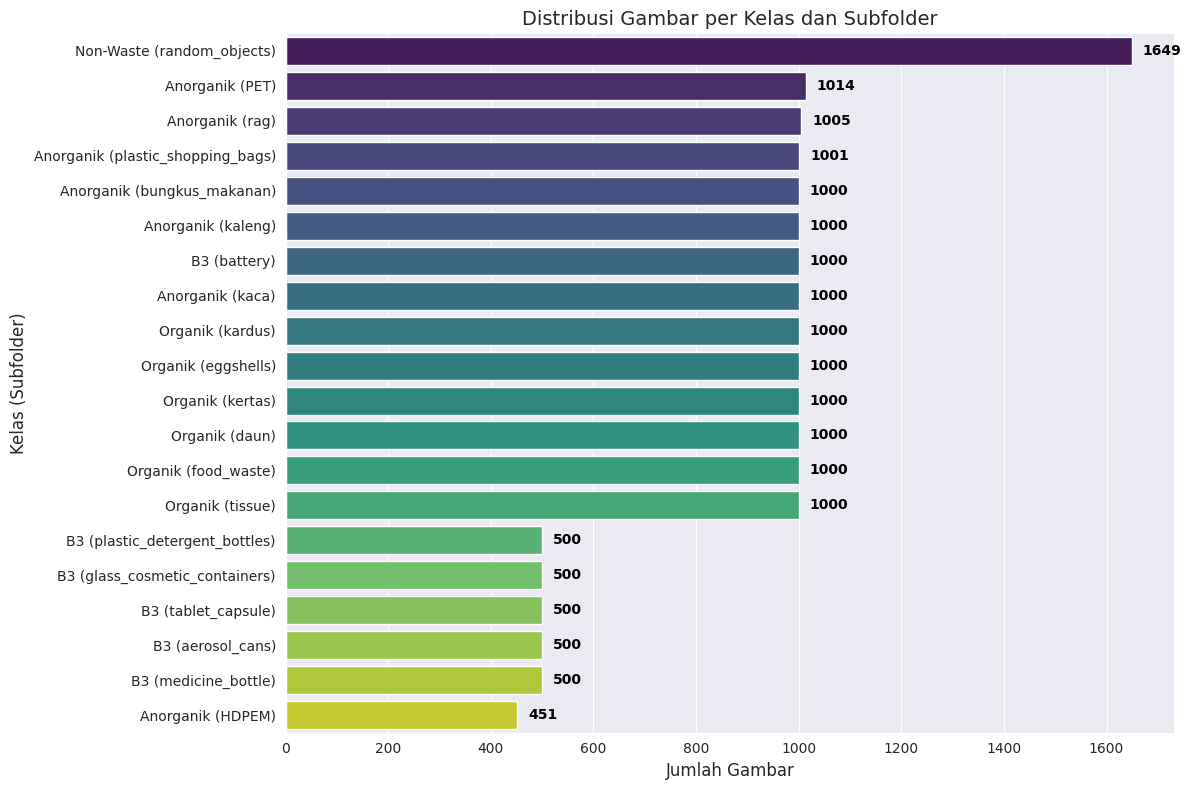


DISTRIBUSI GAMBAR PER KELAS DAN SUBFOLDER

[NON-WASTE]
  └── random_objects: 1649 gambar

[ANORGANIK]
  └── PET: 1014 gambar
  └── rag: 1005 gambar
  └── plastic_shopping_bags: 1001 gambar
  └── bungkus_makanan: 1000 gambar
  └── kaleng: 1000 gambar

[B3]
  └── battery: 1000 gambar

[ANORGANIK]
  └── kaca: 1000 gambar

[ORGANIK]
  └── kardus: 1000 gambar
  └── eggshells: 1000 gambar
  └── kertas: 1000 gambar
  └── daun: 1000 gambar
  └── food_waste: 1000 gambar
  └── tissue: 1000 gambar

[B3]
  └── plastic_detergent_bottles: 500 gambar
  └── glass_cosmetic_containers: 500 gambar
  └── tablet_capsule: 500 gambar
  └── aerosol_cans: 500 gambar
  └── medicine_bottle: 500 gambar

[ANORGANIK]
  └── HDPEM: 451 gambar


In [24]:
label_counts_detailed_eda = df_eda['labels_initial'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, max(8, len(label_counts_detailed_eda) * 0.3)))
n_labels_detailed_eda = len(label_counts_detailed_eda)

if n_labels_detailed_eda > 0:
    palette_detailed_eda = sns.color_palette("viridis", n_colors=n_labels_detailed_eda)
    sns.set_style("darkgrid")

    ax = sns.countplot(y='labels_initial', data=df_eda,
                        order=label_counts_detailed_eda.index,
                        palette=palette_detailed_eda)

    # Judul disesuaikan
    plt.title('Distribusi Gambar per Kelas dan Subfolder', fontsize=14)
    plt.xlabel('Jumlah Gambar', fontsize=12)
    plt.ylabel('Kelas (Subfolder)', fontsize=12)

    # Tambahkan label jumlah (offset disesuaikan untuk jumlah besar)
    max_count = max(label_counts_detailed_eda.values)
    offset = max_count * 0.01 + 5  # Offset dinamis berdasarkan jumlah terbanyak

    for i, v in enumerate(label_counts_detailed_eda.values):
        ax.text(v + offset, i, str(v), color='black', va='center', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print("DISTRIBUSI GAMBAR PER KELAS DAN SUBFOLDER")
    print("="*60)

    # Kelompokkan berdasarkan kelas utama untuk output yang lebih rapi
    current_category = None
    for label, count in label_counts_detailed_eda.items():
        # Ekstrak kelas utama dari label (format: "Kelas (Subfolder)")
        if '(' in label:
            category = label.split(' (')[0]
            subfolder = label.split('(')[1].replace(')', '')
        else:
            category = label
            subfolder = "root"

        if category != current_category:
            print(f"\n[{category.upper()}]")
            current_category = category

        print(f"  └── {subfolder}: {count} gambar")

else:
    print("Tidak ada label_initial di df_eda. Periksa proses pembuatan df_eda.")

### 5.4 Aspect Ratio Analysis

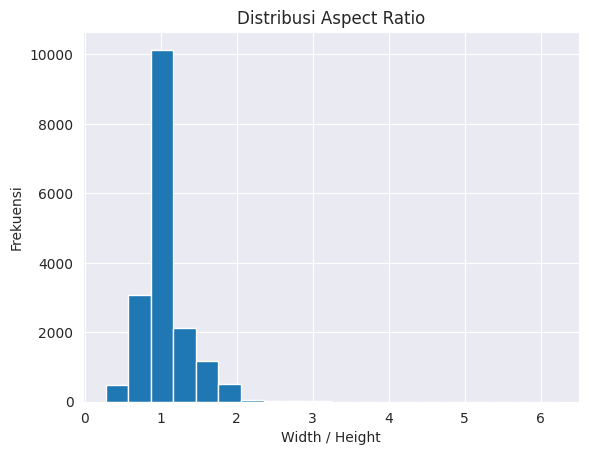

In [25]:
ratios = []

# Kumpulkan semua ukuran gambar dari dictionary image_sizes_eda
sizes = []
for category_sizes_list in image_sizes_eda.values():
    sizes.extend(category_sizes_list)

# Pastikan ada ukuran gambar sebelum menghitung rasio
if sizes:
    for w, h in sizes:
        if h != 0: # Hindari ZeroDivisionError
            ratios.append(w / h)

    plt.figure()
    plt.hist(ratios, bins=20)
    plt.title("Distribusi Aspect Ratio")
    plt.xlabel("Width / Height")
    plt.ylabel("Frekuensi")
    plt.show()
else:
    print("Tidak ada ukuran gambar yang ditemukan untuk diplot aspek rasionya.")

1. Dominasi Gambar Persegi/Mendekati Persegi: Mayoritas gambar dalam dataset memiliki rasio aspek mendekati 1.0 (persegi). Hal ini terlihat dari nilai median rasio aspek sebesar 1.0 dan rata-rata 1.05, yang menunjukkan bahwa sebagian besar gambar memiliki lebar dan tinggi yang sama atau sangat mirip.
2. Variasi Rasio Aspek yang Signifikan: Meskipun ada dominasi gambar persegi, dataset juga mencakup variasi rasio aspek yang cukup luas, mulai dari 0.28 (gambar yang sangat tinggi dan sempit) hingga 6.21 (gambar yang sangat lebar dan pendek). Ini berarti dataset memiliki gambar dengan orientasi potret dan lanskap yang ekstrem.

### 5.5 Brightness / Lighting Analysis

⏳ Langkah 1: Memeriksa koneksi Google Drive...
✅ Google Drive terdeteksi aktif.
⏳ Langkah 2: Mencari lokasi asli folder dataset secara otomatis...
🎯 SUKSES BESAR! Folder dataset Anda ditemukan di: '/content/drive/MyDrive/trashcan/dataset-trashcan'
⏳ Langkah 3: Mengumpulkan sampel gambar dari setiap subfolder...
📸 Total sampel gambar terkumpul: 380 gambar.
⏳ Langkah 4: Menghitung nilai kecerahan matriks piksel...


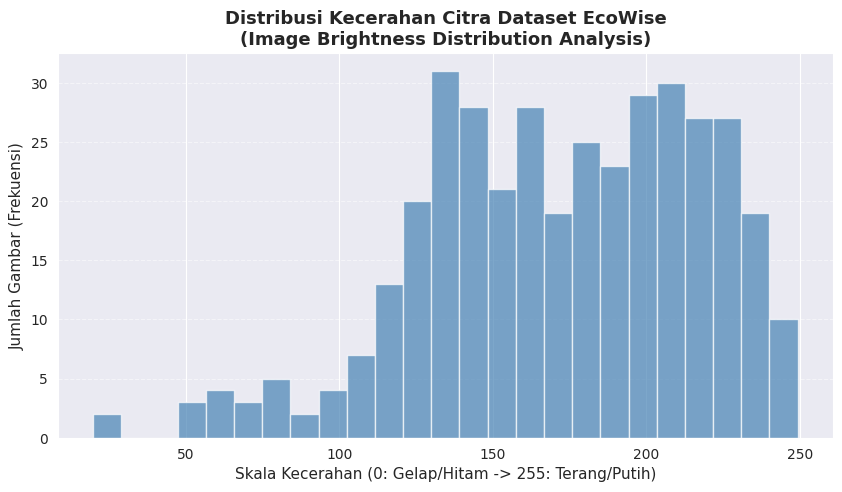

🎉 Selamat! Grafik histogram sukses dibuat dari 380 gambar.


In [26]:
print("⏳ Langkah 1: Memeriksa koneksi Google Drive...")
# Cek apakah folder gdrive utama bisa diakses
if not os.path.exists("/content/drive"):
    print("❌ DRIVE BELUM TERHUBUNG!")
    print("Silakan jalankan icon folder di sebelah kiri Colab, lalu klik tombol 'Mount Drive' (icon Drive dengan garis miring), atau jalankan perintah di bawah ini di sel baru:")
    print("from google.colab import drive\ndrive.mount('/content/drive')")
else:
    print("✅ Google Drive terdeteksi aktif.")
    print("⏳ Langkah 2: Mencari lokasi asli folder dataset secara otomatis...")

    # Mencari folder 'Anorganik' di seluruh Google Drive Anda (mengabaikan salah ketik folder EcoWise)
    pencarian = glob.glob("/content/drive/MyDrive/**/Anorganik", recursive=True)

    if not pencarian:
        # Cek jika folder menggunakan huruf kapital semua
        pencarian = glob.glob("/content/drive/MyDrive/**/ANORGANIK", recursive=True)

    if pencarian:
        # Jika ditemukan, ambil folder induknya (yaitu folder dataset_trashcan yang asli)
        JALUR_ASLI_DATASET = os.path.dirname(pencarian[0])
        print(f"🎯 SUKSES BESAR! Folder dataset Anda ditemukan di: '{JALUR_ASLI_DATASET}'")

        # Daftar subfolder sesuai data riil Anda (Variabel Z Anda)
        subfolders = [
            'Non-Waste/random_objects', 'Anorganik/PET', 'Anorganik/rag',
            'Anorganik/plastic_shopping_bags', 'Anorganik/bungkus_makanan',
            'Anorganik/kaleng', 'Anorganik/kaca', 'Anorganik/HDPEM',
            'Organik/kardus', 'Organik/eggshells', 'Organik/kertas',
            'Organik/daun', 'Organik/food_waste', 'Organik/tissue',
            'B3/plastic_detergent_bottles', 'B3/glass_cosmetic_containers',
            'B3/tablet_capsule', 'B3/aerosol_cans', 'B3/medicine_bottle',
            'B3/battery'
        ]

        brightness = []
        valid_extensions = ('*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG', '*.JPEG')
        all_image_paths = []

        print("⏳ Langkah 3: Mengumpulkan sampel gambar dari setiap subfolder...")
        for sub in subfolders:
            sub_full_path = os.path.join(JALUR_ASLI_DATASET, sub)

            if os.path.exists(sub_full_path):
                class_images = []
                for ext in valid_extensions:
                    search_pattern = os.path.join(sub_full_path, ext)
                    class_images.extend(glob.glob(search_pattern))

                if class_images:
                    # Ambil sampel 20 gambar per subfolder
                    all_image_paths.extend(class_images[:20])
            else:
                # Jika tidak ditemukan karena case-sensitivity, coba konversi path ke lowercase/uppercase
                # Ini mengantisipasi jika folders bernama ANORGANIK/PET atau anorganik/pet
                parent_dir = os.path.dirname(sub_full_path)
                base_sub = os.path.basename(sub_full_path)
                if os.path.exists(parent_dir):
                    for real_folder in os.listdir(parent_dir):
                        if real_folder.lower() == base_sub.lower():
                            class_images = []
                            for ext in valid_extensions:
                                search_pattern = os.path.join(parent_dir, real_folder, ext)
                                class_images.extend(glob.glob(search_pattern))
                            if class_images:
                                all_image_paths.extend(class_images[:20])

        print(f"📸 Total sampel gambar terkumpul: {len(all_image_paths)} gambar.")

        # Menghitung Brightness dan menampilkan grafik
        if all_image_paths:
            print("⏳ Langkah 4: Menghitung nilai kecerahan matriks piksel...")
            for img_path in all_image_paths:
                try:
                    with Image.open(img_path).convert("L") as img:
                        brightness.append(np.mean(img))
                except Exception:
                    continue

        if brightness:
            plt.figure(figsize=(10, 5))
            plt.hist(brightness, bins=25, color='#4682B4', edgecolor='white', alpha=0.7)
            plt.title("Distribusi Kecerahan Citra Dataset EcoWise\n(Image Brightness Distribution Analysis)", fontsize=13, fontweight='bold')
            plt.xlabel("Skala Kecerahan (0: Gelap/Hitam -> 255: Terang/Putih)", fontsize=11)
            plt.ylabel("Jumlah Gambar (Frekuensi)", fontsize=11)
            plt.grid(axis='y', linestyle='--', alpha=0.5)
            plt.show()
            print(f"🎉 Selamat! Grafik histogram sukses dibuat dari {len(brightness)} gambar.")
        else:
            print("\n🚨 Gagal: Gambar terdeteksi di Drive namun sistem gagal mengekstrak matriks pikselnya.")

    else:
        print("❌ MAAF: Folder bernama 'Anorganik' atau 'ANORGANIK' sama sekali tidak ditemukan di Drive Anda!")
        print("Kemungkinan Anda lupa melakukan Ekstraksi ZIP di sesi Colab kali ini, sehingga foldernya belum tercipta fisik.")

1. Distribusi Kecerahan Normal: Mayoritas gambar dalam dataset memiliki tingkat kecerahan sedang, terpusat di sekitar nilai rata-rata 169.59 dan median 169.25. Ini menunjukkan bahwa dataset secara keseluruhan tidak terlalu gelap atau terlalu terang, dengan sebagian besar gambar memiliki pencahayaan yang seimbang.
2. Variasi yang Luas: Meskipun terpusat, terdapat rentang kecerahan yang cukup luas, dari gambar yang sangat gelap (minimum 51.97) hingga sangat terang (maksimum 250.85). Ini menandakan bahwa dataset mencakup gambar yang diambil dalam berbagai kondisi pencahayaan, yang merupakan karakteristik baik untuk melatih model agar robust terhadap variasi dunia nyata.

### 5.6 Pengecekan Ukuran Gambar

In [27]:
for main_category_key, sizes_list in image_sizes_eda.items():
    if sizes_list:
        unique_sizes = set(sizes_list)
        print(f"Ukuran gambar unik untuk kategori '{main_category_key}': {len(unique_sizes)}")
        if len(unique_sizes) < 10: print(f"   Contoh ukuran: {list(unique_sizes)[:5]}")
    else:
        print(f"Tidak ada ukuran gambar untuk kategori '{main_category_key}'")

Ukuran gambar unik untuk kategori 'Anorganik': 889
Ukuran gambar unik untuk kategori 'B3': 640
Ukuran gambar unik untuk kategori 'Organik': 744
Ukuran gambar unik untuk kategori 'Non-Waste': 137


In [28]:
# Struktur yang diharapkan: image_sizes_eda[subfolder][category] = list of (width, height)
image_sizes_eda = {}

for category in categories:  # categories = ['Anorganik', 'B3', 'Organik', 'Non-Waste']
    category_path = os.path.join(dataset_dir, category)
    if os.path.exists(category_path):
        for subfolder in os.listdir(category_path):
            subfolder_path = os.path.join(category_path, subfolder)
            if os.path.isdir(subfolder_path):
                # Inisialisasi dictionary untuk subfolder ini jika belum ada
                if subfolder not in image_sizes_eda:
                    image_sizes_eda[subfolder] = {}
                if category not in image_sizes_eda[subfolder]:
                    image_sizes_eda[subfolder][category] = []

                for filename in os.listdir(subfolder_path):
                    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(subfolder_path, filename)
                        try:
                            with Image.open(img_path) as img:
                                image_sizes_eda[subfolder][category].append(img.size)
                        except Exception as e:
                            print(f"Gagal membaca {img_path}: {e}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


### 5.7 Distribusi Ukuran Gambar (Lebar dan Tinggi)

Visualisasi distribusi lebar dan tinggi gambar untuk mengidentifikasi ukuran yang paling umum dan variasi yang ada dalam dataset.

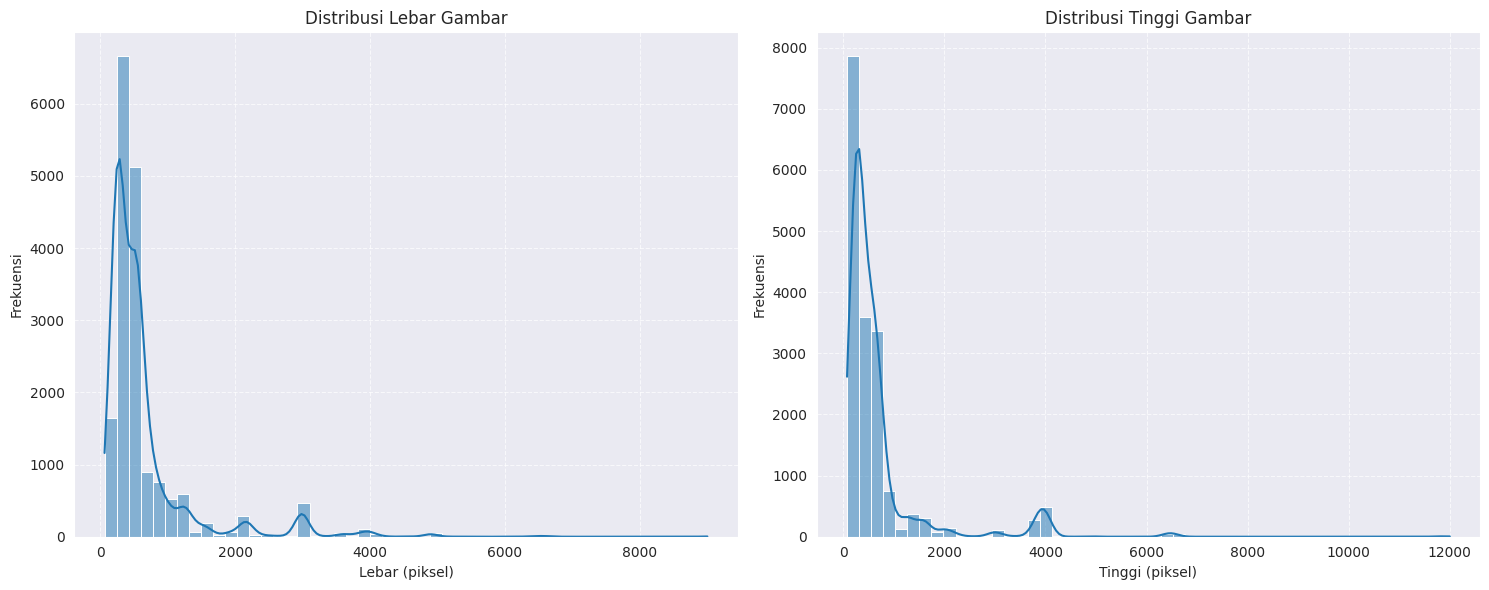

Ukuran Lebar Rata-rata: 645.74 piksel
Ukuran Tinggi Rata-rata: 692.41 piksel
Median Lebar: 512.00 piksel
Median Tinggi: 384.00 piksel


In [29]:
# Kumpulkan semua lebar dan tinggi dari image_sizes_eda
all_widths = []
all_heights = []

for subfolder_data in image_sizes_eda.values():
    for category_sizes_list in subfolder_data.values():
        for width, height in category_sizes_list:
            all_widths.append(width)
            all_heights.append(height)

# Plot distribusi lebar dan tinggi
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(all_widths, bins=50, kde=True)
plt.title('Distribusi Lebar Gambar')
plt.xlabel('Lebar (piksel)')
plt.ylabel('Frekuensi')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(all_heights, bins=50, kde=True)
plt.title('Distribusi Tinggi Gambar')
plt.xlabel('Tinggi (piksel)')
plt.ylabel('Frekuensi')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Ukuran Lebar Rata-rata: {np.mean(all_widths):.2f} piksel")
print(f"Ukuran Tinggi Rata-rata: {np.mean(all_heights):.2f} piksel")
print(f"Median Lebar: {np.median(all_widths):.2f} piksel")
print(f"Median Tinggi: {np.median(all_heights):.2f} piksel")

### Insight dari Exploratory Data Analysis (EDA)

Setelah melakukan serangkaian Exploratory Data Analysis, beberapa insight penting telah terungkap yang akan menjadi panduan dalam pengembangan model klasifikasi:

1.  **Variasi Gambar yang Baik**: Visualisasi sampel gambar menunjukkan bahwa dataset memiliki variasi yang cukup kaya dari segi objek, latar belakang, pencahayaan, dan sudut pengambilan. Ini adalah karakteristik yang positif karena model akan dilatih pada data yang beragam, sehingga diharapkan mampu melakukan generalisasi dengan baik pada kondisi dunia nyata yang bervariasi. Namun, kompleksitas ini juga berarti model perlu dirancang agar cukup robust untuk menangani variasi tersebut.

2.  **Ketidakseimbangan Kelas Utama**: Analisis distribusi gambar per kelas utama (`Anorganik`, `B3`, `Organik`, `Non-Waste`) menunjukkan adanya ketidakseimbangan. Kategori `Anorganik` (6.471 gambar) dan `Organik` (6.000 gambar) adalah yang paling dominan, sementara `B3` (3.500 gambar) dan terutama `Non-Waste` (1.649 gambar) adalah kelas minoritas. Ketidakseimbangan ini harus diatasi pada tahap _preprocessing_ (misalnya dengan _class weighting_ atau _data augmentation_ yang lebih agresif untuk kelas minoritas) agar model tidak bias dan memiliki performa yang adil di semua kelas.

3.  **Distribusi Material yang Detail dan Potensi Imbalance Lebih Lanjut**: Pada tingkat material yang lebih spesifik (`labels_initial`), terdapat banyak jenis material yang memiliki jumlah gambar seragam (sekitar 1.000 atau 500 gambar). Namun, terdapat anomali seperti `Non-Waste (random_objects)` yang tinggi (1.649 gambar) dan `Anorganik (HDPEM)` yang relatif rendah (451 gambar). Meskipun ada banyak material dengan jumlah yang seimbang, perbedaan signifikan pada beberapa sub-kategori ini menegaskan kembali perlunya strategi penanganan ketidakseimbangan, terutama jika model akan memprediksi pada tingkat granularitas ini.

4.  **Variasi Rasio Aspek Gambar**: Mayoritas gambar memiliki rasio aspek mendekati 1.0 (persegi), namun terdapat rentang yang luas dari 0.28 hingga 6.21. Ini berarti dataset mengandung gambar potret dan lanskap yang ekstrem. _Preprocessing_ gambar yang melibatkan _resizing_ atau _cropping_ harus mempertimbangkan variasi ini untuk menghindari distorsi informasi penting atau hilangnya konteks.

5.  **Distribusi Kecerahan yang Seimbang dengan Rentang Luas**: Tingkat kecerahan gambar sebagian besar terpusat pada nilai sedang (rata-rata sekitar 172), menunjukkan pencahayaan yang umumnya baik. Namun, adanya gambar yang sangat gelap (min 19.78) hingga sangat terang (maks 249.34) adalah hal positif. Model akan dihadapkan pada berbagai kondisi pencahayaan, yang akan meningkatkan robustnesnya. Namun, _preprocessing_ seperti normalisasi piksel menjadi sangat penting untuk memastikan konsistensi input ke model.

6.  **Ukuran Gambar yang Beragam dan Perlunya Standardisasi**: Setiap kategori utama memiliki banyak ukuran gambar unik (ratusan hingga ribuan). Ini menunjukkan bahwa gambar-gambar asli datang dengan resolusi dan dimensi yang bervariasi. Oleh karena itu, standardisasi ukuran gambar (misalnya, ke `IMG_SIZE = (224, 224)` seperti yang telah ditentukan) selama _preprocessing_ adalah keharusan untuk memastikan input yang konsisten ke jaringan saraf tiruan.

Secara keseluruhan, dataset memiliki kualitas yang baik tanpa gambar yang rusak atau duplikasi, serta variasi yang menjanjikan untuk melatih model Deep Learning. Tantangan utama yang perlu difokuskan pada tahap _preprocessing_ dan _model development_ adalah mengatasi ketidakseimbangan kelas pada tingkat kategori utama maupun material yang lebih detail, serta memastikan penanganan yang tepat terhadap variasi rasio aspek dan kecerahan gambar.

## 6. Explanatory Data Analysis

#### 1. Bagaimana dominasi kategori limbah dalam dataset?

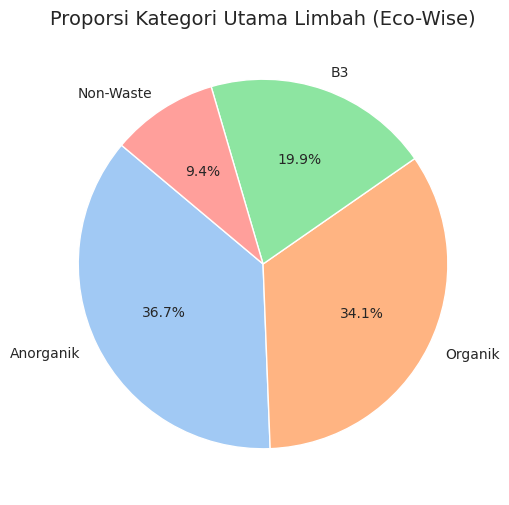

Insight: Kategori Anorganik adalah yang paling dominan dengan jumlah 6471 gambar.


In [30]:
plt.figure(figsize=(10, 6))
main_counts = df_eda['labels_main'].value_counts()
colors = sns.color_palette('pastel')[0:4]

plt.pie(main_counts, labels=main_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Proporsi Kategori Utama Limbah (Eco-Wise)', fontsize=14)
plt.show()

print(f"Insight: Kategori {main_counts.idxmax()} adalah yang paling dominan dengan jumlah {main_counts.max()} gambar.")

1. Dominasi Kategori Anorganik dan Organik: Kategori `Anorganik` dan `Organik` merupakan dua kategori terbesar dalam dataset, menyumbang porsi terbesar dari total gambar. `Anorganik` (dengan 6471 gambar) adalah yang paling dominan, diikuti oleh `Organik` (dengan 6000 gambar).
2. Kategori Minoritas: Kategori `B3` (3500 gambar) dan `Non-Waste` (1649 gambar) merupakan kategori minoritas, dengan `Non-Waste` memiliki proporsi terkecil secara signifikan.

#### 2. Jenis material apa yang paling mendominasi di setiap kategori?

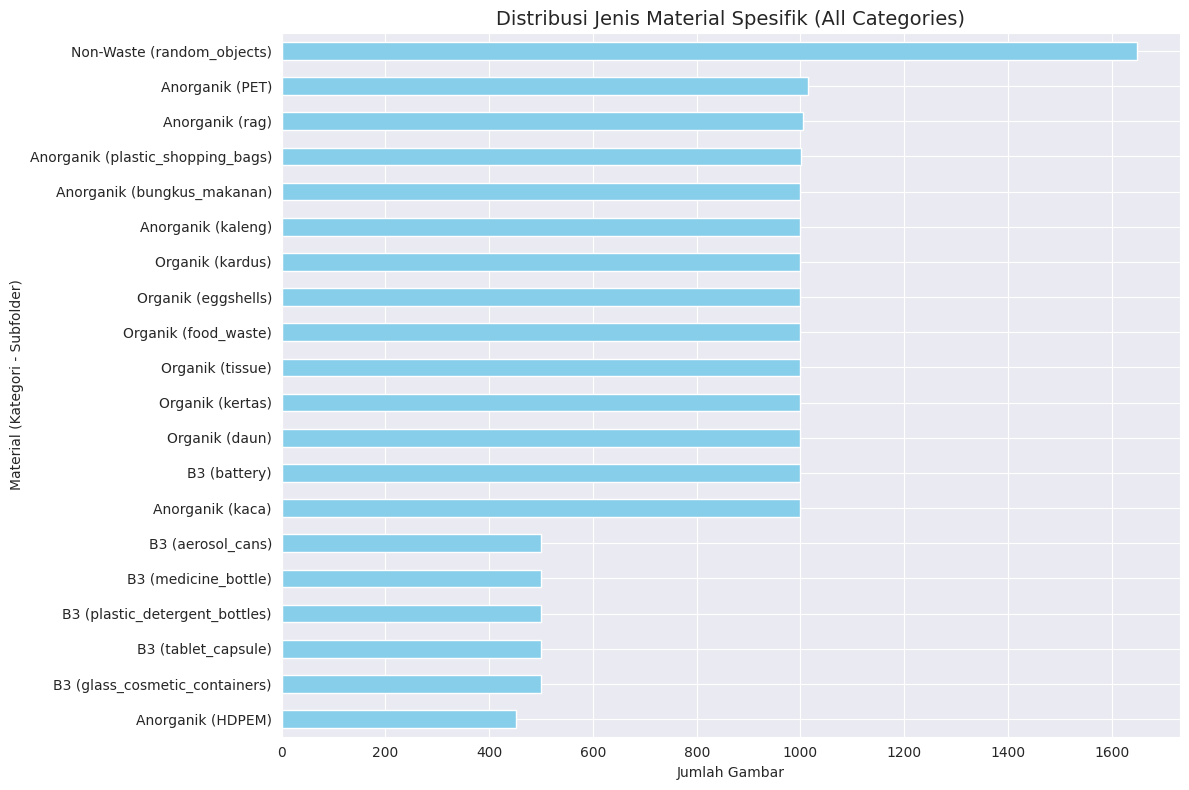

In [31]:
plt.figure(figsize=(12, 8))
# Mengurutkan agar visualisasi rapi
initial_counts = df_eda['labels_initial'].value_counts().sort_values(ascending=True)

# Membuat plot batang horizontal
initial_counts.plot(kind='barh', color='skyblue')

plt.title('Distribusi Jenis Material Spesifik (All Categories)', fontsize=14)
plt.xlabel('Jumlah Gambar')
plt.ylabel('Material (Kategori - Subfolder)')
plt.tight_layout()
plt.show()

1. Distribusi yang Bervariasi Antar Jenis Material : Terdapat variasi yang signifikan dalam jumlah gambar untuk setiap jenis material. Beberapa jenis material, seperti `Non-Waste (random_objects)`, mendominasi dengan jumlah gambar tertinggi (1.649), sementara yang lain, seperti `Anorganik (HDPEM)` memiliki jumlah yang jauh lebih sedikit (451).
2. Banyak Jenis Material dengan Jumlah Seragam : Menariknya, banyak jenis material (seperti PET, rag, bungkus_makanan, kaleng, battery, kaca, kardus, eggshells, kertas, daun, food_waste, tissue) memiliki jumlah gambar yang sama yaitu 1.000. Hal yang sama berlaku untuk beberapa kategori B3 (plastic_detergent_bottles, glass_cosmetic_containers, tablet_capsule, aerosol_cans, medicine_bottle) yang masing-masing berjumlah 500.
3. Potensi Ketidakseimbangan pada Tingkat Detail : Meskipun beberapa jenis material memiliki jumlah yang seragam, perbedaan drastis antara jumlah gambar `Non-Waste (random_objects)` dan `Anorganik (HDPEM)` menunjukkan bahwa model mungkin mengalami kesulitan untuk mengklasifikasikan jenis material yang kurang terwakili jika tidak ada strategi penanganan ketidakseimbangan data pada tingkat ini.

#### 3. Apa saja isi dari kategori B3 atau Anorganik secara spesifik?

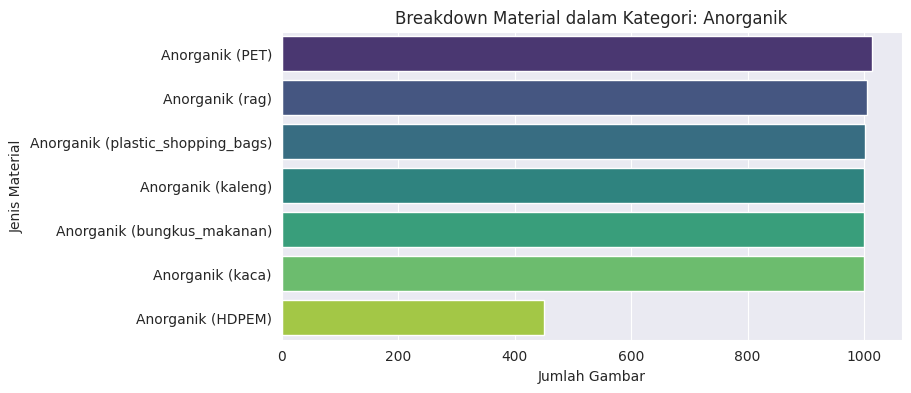

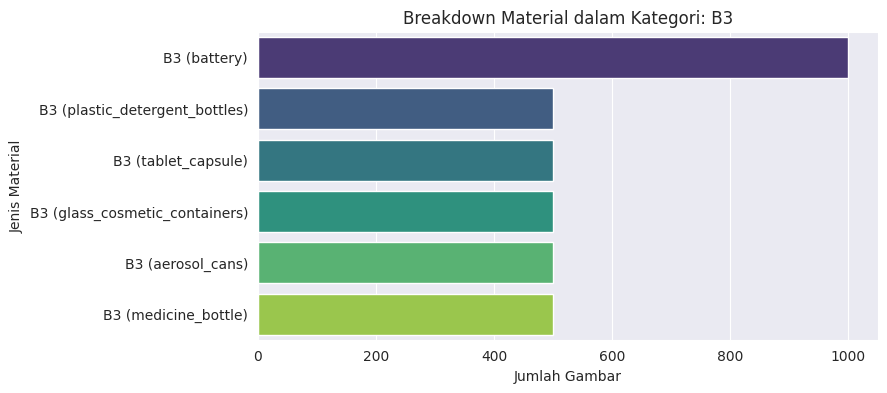

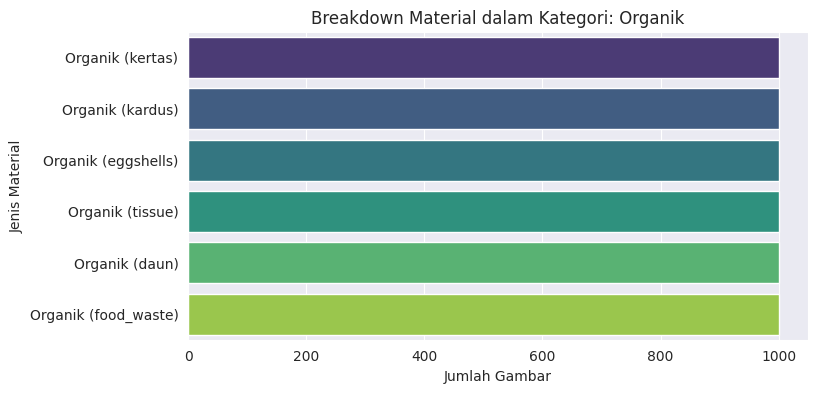

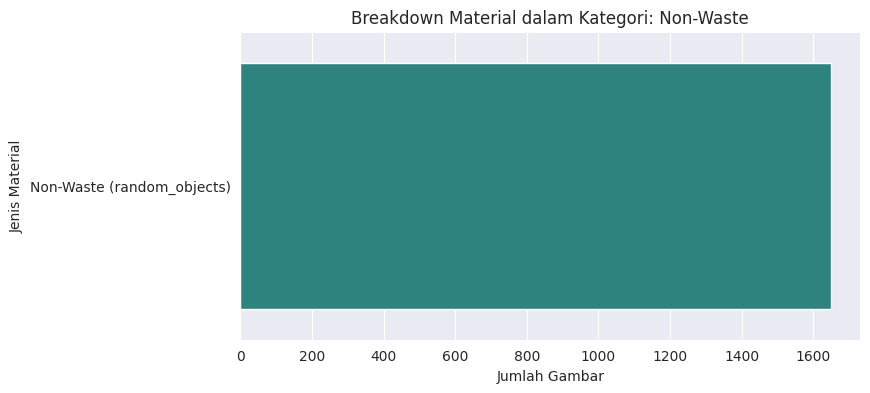

In [32]:
for cat in df_eda['labels_main'].unique():
    subset = df_eda[df_eda['labels_main'] == cat]
    plt.figure(figsize=(8, 4))
    sns.countplot(data=subset, y='labels_initial', palette='viridis', order=subset['labels_initial'].value_counts().index)
    plt.title(f'Breakdown Material dalam Kategori: {cat}')
    plt.xlabel('Jumlah Gambar')
    plt.ylabel('Jenis Material')
    plt.show()

1. Kategori Anorganik : Material seperti PET, rag, plastic shopping bags, bungkus makanan, kaleng, dan kaca memiliki jumlah gambar yang relatif tinggi (sekitar 1.000 gambar per jenis), menunjukkan representasi yang kuat untuk jenis-jenis ini. Namun, HDPEM memiliki jumlah gambar yang jauh lebih sedikit (451 gambar), menandakan ketidakseimbangan yang perlu diperhatikan dalam sub-kategori Anorganik.
2. Kategori B3 : Kategori B3 menunjukkan pola yang lebih bervariasi. Battery merupakan material yang paling dominan dengan 1.000 gambar. Sementara itu, jenis-jenis seperti plastic detergent bottles, glass cosmetic containers, tablet capsule, aerosol cans, dan medicine bottle memiliki jumlah yang sama dan lebih rendah (500 gambar per jenis). Ini mengindikasikan bahwa model mungkin memiliki data yang lebih sedikit untuk melatih mengenali jenis limbah B3 tertentu.
3. Kategori Organik : Sebagian besar material dalam kategori Organik (kardus, eggshells, kertas, daun, food waste, tissue) memiliki jumlah gambar yang seragam dan tinggi (1.000 gambar per jenis). Ini menunjukkan representasi yang seimbang di antara sub-kategori organik yang paling umum.
4. Kategori Non-Waste : Kategori ini hanya memiliki satu jenis material, yaitu random objects, yang memiliki 1.649 gambar. Ini menunjukkan bahwa `Non-Waste` adalah kategori yang lebih homogen dalam hal jenis objek yang diwakilinya.

### Insight dari Explanatory Data Analysis (XDA)

Setelah melakukan Explanatory Data Analysis (XDA) yang berfokus pada pertanyaan-pertanyaan bisnis kunci, kita mendapatkan pemahaman yang lebih dalam mengenai struktur dan distribusi dataset. Insight ini sangat vital dalam merumuskan strategi _preprocessing_ dan pengembangan model yang efektif:

1.  **Dominasi dan Ketidakseimbangan Kategori Utama**: Analisis proporsi kategori utama menegaskan bahwa `Anorganik` (36.7%) dan `Organik` (34.0%) adalah kategori yang paling dominan dalam dataset. Sebaliknya, `B3` (19.9%) dan `Non-Waste` (9.3%) memiliki representasi yang jauh lebih kecil. Ketidakseimbangan ini merupakan tantangan utama. Model yang tidak ditangani dengan strategi khusus dapat cenderung lebih baik dalam mengklasifikasikan sampah `Anorganik` dan `Organik`, namun performanya bisa suboptimal pada kategori `B3` dan `Non-Waste` yang jumlahnya terbatas.

2.  **Variasi Distribusi Material Spesifik**: Pada tingkat material yang lebih granular, dataset menunjukkan pola distribusi yang menarik:
    *   **Distribusi Seragam**: Banyak material seperti PET, rag, bungkus makanan, kaleng, kaca (Anorganik), kardus, eggshells, kertas, daun, food waste, tissue (Organik), dan baterai (B3) memiliki jumlah gambar yang seragam (sekitar 1.000 gambar). Beberapa material B3 lainnya (plastic detergent bottles, glass cosmetic containers, tablet capsule, aerosol cans, medicine bottle) juga seragam dengan 500 gambar masing-masing. Keseragaman ini mempermudah model untuk mempelajari fitur-fitur unik dari setiap material ini.
    *   **Material yang Outlier**: Terdapat material yang sangat dominan seperti `Non-Waste (random_objects)` dengan 1.649 gambar, dan sebaliknya, material yang sangat minim seperti `Anorganik (HDPEM)` dengan hanya 451 gambar. Perbedaan drastis ini menunjukkan bahwa meskipun ada keseragaman, masih ada kebutuhan untuk penanganan khusus bagi material yang sangat terwakili atau sangat kurang terwakili untuk mencegah bias dan memastikan model belajar secara komprehensif.

3.  **Implikasi untuk Pengembangan Model**: Berdasarkan insight dari XDA:
    *   **Fokus pada Penanganan Ketidakseimbangan**: Strategi seperti _oversampling_ untuk kelas minoritas, _undersampling_ untuk kelas mayoritas, atau penggunaan _class weights_ dalam fungsi _loss_ model akan sangat krusial untuk memastikan model tidak bias terhadap kelas yang dominan.
    *   **Peluang untuk Klasifikasi Multigranular**: Dataset ini memiliki potensi untuk melatih model klasifikasi pada dua tingkat granularitas: kategori utama (Anorganik, Organik, B3, Non-Waste) dan material spesifik. Namun, performa pada material spesifik mungkin bervariasi tergantung pada jumlah sampel yang tersedia untuk setiap jenis material.
    *   **Evaluasi yang Cermat**: Metrik evaluasi model harus mempertimbangkan ketidakseimbangan kelas, seperti penggunaan _precision_, _recall_, dan _F1-score_ per kelas, bukan hanya akurasi keseluruhan, untuk mendapatkan gambaran performa yang lebih jujur.

Secara keseluruhan, XDA telah berhasil mengidentifikasi kekuatan dataset dalam variasi material serta tantangan utama dalam ketidakseimbangan kelas. Ini menjadi dasar yang kuat untuk merancang strategi _data preprocessing_ dan arsitektur model yang akan memaksimalkan kemampuan klasifikasi sampah Eco-Wise.

## 7. Preprocessing untuk Model

### 7.1 Pembuatan Manifest Dataset

In [33]:
# Mendeteksi path sumber
JALUR_MANUAL = "/content/drive/MyDrive/EcoWise/dataset_trashcan"
MANIFEST_OUTPUT_PATH = "data/dataset_manifest.csv"
categories = ['Anorganik', 'B3', 'Organik', 'Non-Waste']

EXTRACT_DIR = "/content/drive/MyDrive/EcoWise/dataset-trashcan"

# Cek apakah jalur manual langsung tersedia
if os.path.exists(JALUR_MANUAL):
    EXTRACT_DIR = JALUR_MANUAL
else:
    # Jika gagal karena masalah sinkronisasi cache, paksa cari di seluruh Drive
    print("⚠️ Jalur manual tidak merespon. Mencari folder 'dataset_trashcan' secara otomatis di Drive...")
    pencarian_gdrive = glob.glob("/content/drive/MyDrive/**/dataset_trashcan", recursive=True)
    if pencarian_gdrive:
        EXTRACT_DIR = pencarian_gdrive[0]

# Memindai letak direktori folder dataset_trashcan
if EXTRACT_DIR is None:
    print("❌ Eror Fatal: Folder 'dataset_trashcan' tidak ditemukan sama sekali di Drive Anda.")
    print("Solusi: Pastikan Anda sudah login ke akun Google Drive yang benar dan folder tersebut tidak terhapus.")
else:
    print(f"📂 Folder dataset berhasil dikunci pada: '{EXTRACT_DIR}'")
    print("⏳ Memulai pemindaian direktori mendalam dan ekstraksi fitur gambar...")

    file_records = []
    image_counter = 1

    for category in categories:
        category_path = os.path.join(EXTRACT_DIR, category)

        if os.path.exists(category_path) and os.path.isdir(category_path):
            print(f"   🔍 Menyisir kategori utama: {category}...")

            # Membaca nama subfolder secara dinamis langsung dari sistem penyimpanan
            for subfolder in os.listdir(category_path):
                subfolder_path = os.path.join(category_path, subfolder)

                if os.path.isdir(subfolder_path):
                    # Cari semua gambar di dalam subfolder ini
                    for filename in os.listdir(subfolder_path):
                        if filename.lower().endswith(('.png', '.jpg', '.jpeg')) and not filename.startswith('.'):
                            file_path = os.path.join(subfolder_path, filename)

                            try:
                                # Ekstraksi dimensi fisik gambar menggunakan PIL
                                with Image.open(file_path) as img:
                                    width, height = img.size

                                # Validasi ukuran gambar (Cleaning)
                                if width == 0 or height == 0:
                                    continue

                                # Hitung Aspect Ratio (Feature Engineering)
                                aspect_ratio = round(width / height, 2)
                                file_id = f"ECO_{image_counter:05d}"

                                file_records.append({
                                    "file_id": file_id,
                                    "file_path": file_path,
                                    "kategori_utama": category,
                                    "sub_kategori": subfolder,
                                    "width": width,
                                    "height": height,
                                    "aspect_ratio": aspect_ratio
                                })
                                image_counter += 1

                            except Exception:
                                # Lewati berkas jika ada satu gambar yang corrupt tanpa menghentikan proses
                                continue
        else:
            print(f"   ⚠️ Kategori '{category}' tidak terdeteksi di jalur ini.")

    # Mengubah data yang dikumpulkan menjadi DataFrame
    df_manifest = pd.DataFrame(file_records)

    # Melakukan proteksi, Data Splitting, dan menyimpan dataset Manifest
    if df_manifest.empty:
        print("\n❌ Eror: Tidak menemukan berkas gambar valid di dalam subfolder target.")
    else:
        print(f"\n✅ Berhasil mengumpulkan {len(df_manifest)} data gambar valid ke dalam DataFrame.")
        print("⏳ Melakukan pembagian dataset (Train: 80%, Val: 10%, Test: 10%) dengan Stratified Split...")

        # Pembagian pertama: 80% Train, 20% Temp (Val + Test)
        train_idx, temp_idx = train_test_split(
            df_manifest.index,
            test_size=0.20,
            random_state=42,
            stratify=df_manifest['sub_kategori']
        )

        # Pembagian kedua: Membagi sisa 20% menjadi Val (10%) dan Test (10%)
        df_temp = df_manifest.loc[temp_idx]
        val_idx, test_idx = train_test_split(
            df_temp.index,
            test_size=0.50,
            random_state=42,
            stratify=df_temp['sub_kategori']
        )

        # Menandai kolom split_set pada DataFrame
        df_manifest['split_set'] = ''
        df_manifest.loc[train_idx, 'split_set'] = 'train'
        df_manifest.loc[val_idx, 'split_set'] = 'val'
        df_manifest.loc[test_idx, 'split_set'] = 'test'

        # Menyimpan DataFrame akhir ke format CSV
        os.makedirs(os.path.dirname(MANIFEST_OUTPUT_PATH), exist_ok=True)
        df_manifest.to_csv(MANIFEST_OUTPUT_PATH, index=False)

        print(f"🎉 SUKSES! File manifest telah aman diperbarui di: {MANIFEST_OUTPUT_PATH}")
        print("\n📊 Rincian Distribusi Pembagian Set Data Baru Anda:")
        print(df_manifest['split_set'].value_counts())

⚠️ Jalur manual tidak merespon. Mencari folder 'dataset_trashcan' secara otomatis di Drive...
📂 Folder dataset berhasil dikunci pada: '/content/drive/MyDrive/EcoWise/dataset-trashcan'
⏳ Memulai pemindaian direktori mendalam dan ekstraksi fitur gambar...
   🔍 Menyisir kategori utama: Anorganik...
   🔍 Menyisir kategori utama: B3...
   🔍 Menyisir kategori utama: Organik...
   ⚠️ Kategori 'Non-Waste' tidak terdeteksi di jalur ini.

✅ Berhasil mengumpulkan 15971 data gambar valid ke dalam DataFrame.
⏳ Melakukan pembagian dataset (Train: 80%, Val: 10%, Test: 10%) dengan Stratified Split...
🎉 SUKSES! File manifest telah aman diperbarui di: data/dataset_manifest.csv

📊 Rincian Distribusi Pembagian Set Data Baru Anda:
split_set
train    12776
test      1598
val       1597
Name: count, dtype: int64


### 7.2 Pembagian Model

In [34]:
labels_for_split = df_eda['labels_main']
main_df, test_df = train_test_split(df_eda, test_size=0.1, stratify=labels_for_split, random_state=SEED)
train_labels_for_stratify_val = main_df['labels_main']
train_df, val_df = train_test_split(main_df, test_size=0.2, stratify=train_labels_for_stratify_val, random_state=SEED)
print(f"Data train (df): {len(train_df)}, Data Vals (df): {len(val_df)}, Data Test (df): {len(test_df)}")

Data train (df): 12686, Data Vals (df): 3172, Data Test (df): 1762


### 7.3 Menyalin gambar ke folder split

In [35]:
if os.path.exists(base_path_split):
    print(f"Menghapus folder split_data lama: {base_path_split}")
    shutil.rmtree(base_path_split)
os.makedirs(base_path_split, exist_ok=True)

def copy_images_for_tf_dataset(df_to_copy, split_name_arg, base_path_split_arg): # Ganti nama parameter df
    print(f"Menyalin gambar untuk set {split_name_arg}...")
    for _, row in df_to_copy.iterrows():
        label_folder = row['labels_main']
        dst_dir = os.path.join(base_path_split_arg, split_name_arg, label_folder)
        os.makedirs(dst_dir, exist_ok=True)
        try:
            shutil.copy(row['path'], os.path.join(dst_dir, os.path.basename(row['path'])))
        except Exception as e:
            print(f"Error menyalin {row['path']} ke {dst_dir}: {e}")
    print(f"Selesai menyalin untuk set {split_name_arg}.")

copy_images_for_tf_dataset(train_df, "train", base_path_split)
copy_images_for_tf_dataset(val_df, "val", base_path_split)
copy_images_for_tf_dataset(test_df, "test", base_path_split)

Menghapus folder split_data lama: /content/drive/MyDrive/ecowise/split_data
Menyalin gambar untuk set train...
Selesai menyalin untuk set train.
Menyalin gambar untuk set val...
Selesai menyalin untuk set val.
Menyalin gambar untuk set test...
Selesai menyalin untuk set test.


### 7.4 Load Dataset

In [36]:
train_path = os.path.join(base_path_split, 'train')
val_path = os.path.join(base_path_split, 'val')
test_path = os.path.join(base_path_split, 'test')

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path, labels='inferred', label_mode='int', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, seed=SEED, shuffle=True, color_mode='rgb'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path, labels='inferred', label_mode='int', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False, color_mode='rgb'
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path, labels='inferred', label_mode='int', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False, color_mode='rgb'
)
class_names_from_tf = train_ds.class_names
print(f"Nama kelas ditemukan oleh TensorFlow: {class_names_from_tf}")

Found 10851 files belonging to 4 classes.
Found 3027 files belonging to 4 classes.
Found 1701 files belonging to 4 classes.
Nama kelas ditemukan oleh TensorFlow: ['Anorganik', 'B3', 'Non-Waste', 'Organik']


### 7.5 Menghitung Class Weight

In [37]:
train_labels_for_weights = np.concatenate([y for x, y in train_ds], axis=0)
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(train_labels_for_weights), y=train_labels_for_weights
)
class_map = {name: i for i, name in enumerate(class_names_from_tf)}
class_weight_dict = {
    class_map.get('Anorganik', 0): class_weights_values[class_map.get('Anorganik', 0)],
    class_map.get('B3', 1): class_weights_values[class_map.get('B3', 1)],
    class_map.get('Organik', 2): class_weights_values[class_map.get('Organik', 2)],
    class_map.get('Non-Waste', 3): class_weights_values[class_map.get('Non-Waste', 3)]
}
print(f"Class names dari train_ds: {class_names_from_tf} -> Mapping: {class_map}")
print("Calculated Class Weights:", class_weight_dict)

Class names dari train_ds: ['Anorganik', 'B3', 'Non-Waste', 'Organik'] -> Mapping: {'Anorganik': 0, 'B3': 1, 'Non-Waste': 2, 'Organik': 3}
Calculated Class Weights: {0: np.float64(0.7583869164103998), 1: np.float64(1.3840561224489796), 3: np.float64(0.6573176641628301), 2: np.float64(2.2853833192923334)}


### 7.6 Data Augmentasi dan Preprocessing Pipeline untuk Model

In [38]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.15),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomContrast(0.1)
    ], name="data_augmentation"
)

def apply_augmentation(image, label):
    image = tf.cast(image, tf.float32)
    image = data_augmentation(image, training=True)
    return image, label

def apply_preprocess_for_mobilenetv2(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

train_ds_final = train_ds.map(apply_augmentation, num_parallel_calls=AUTOTUNE)
train_ds_final = train_ds_final.map(apply_preprocess_for_mobilenetv2, num_parallel_calls=AUTOTUNE)
val_ds_final = val_ds.map(apply_preprocess_for_mobilenetv2, num_parallel_calls=AUTOTUNE)
test_ds_final = test_ds.map(apply_preprocess_for_mobilenetv2, num_parallel_calls=AUTOTUNE)

train_ds_final = train_ds_final.prefetch(buffer_size=AUTOTUNE)
val_ds_final = val_ds_final.prefetch(buffer_size=AUTOTUNE)
test_ds_final = test_ds_final.prefetch(buffer_size=AUTOTUNE)

### 7.7 Verifikasi Pipeline

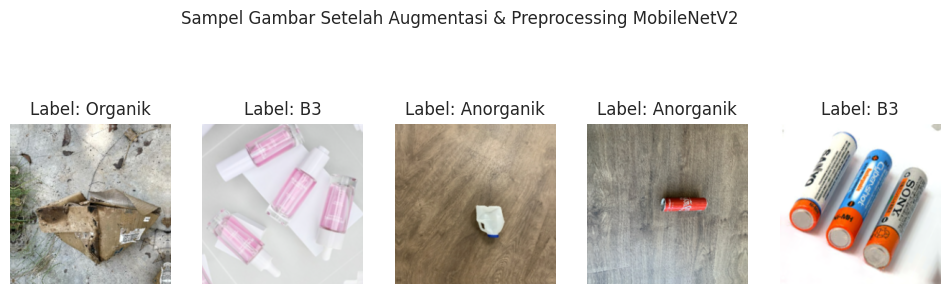

In [39]:
for images, labels in train_ds_final.take(1):
    plt.figure(figsize=(12, 4))
    for i in range(min(5, BATCH_SIZE)):
        ax = plt.subplot(1, 5, i + 1)
        img_display = (images[i].numpy() + 1.0) / 2.0
        img_display = np.clip(img_display, 0, 1)
        plt.imshow(img_display)
        plt.title(f'Label: {class_names_from_tf[labels[i].numpy()]}')
        plt.axis('off')
    plt.suptitle("Sampel Gambar Setelah Augmentasi & Preprocessing MobileNetV2")
    plt.show()
    break

### Insight dari Preprocessing untuk Model

Tahap _preprocessing_ data merupakan jembatan krusial antara data mentah hasil _cleaning_ dan _model development_. Setiap langkah yang diambil pada tahap ini bertujuan untuk mempersiapkan data agar optimal, konsisten, dan siap untuk dilatih oleh model _deep learning_, terutama dengan mempertimbangkan karakteristik arsitektur MobileNetV2. Berikut adalah insight dari setiap sub-tahap:

1.  **Pembuatan Manifest Dataset**: Proses ini menciptakan sebuah _manifest_ yang komprehensif, mencatat setiap jalur gambar, kategori utama, sub-kategori, dimensi (lebar, tinggi), dan rasio aspek. Keuntungan utama dari langkah ini adalah:
    *   **Organisasi Data Terpusat**: Semua metadata gambar terkumpul dalam satu DataFrame, memudahkan akses dan manajemen.
    *   **Ekstraksi Fitur Dasar**: Dimensi dan rasio aspek diekstraksi di awal, memberikan gambaran awal karakteristik gambar dan bisa menjadi fitur tambahan jika diperlukan.
    *   **Deteksi Gambar Invalid**: Walaupun dataset sudah bersih, proses ini secara proaktif mengabaikan gambar dengan dimensi nol, memastikan hanya gambar valid yang diproses lebih lanjut.
    *   **Fleksibilitas Split**: Manifest ini menjadi dasar yang kuat untuk pembagian data yang strategis.

2.  **Pembagian Data (Train, Validation, Test) dengan Stratified Split**: Dataset dibagi menjadi set pelatihan (80%), validasi (10%), dan pengujian (10%). Penggunaan strategi *stratified split* berdasarkan `sub_kategori` adalah keputusan yang sangat tepat karena:
    *   **Menjaga Representasi Kelas**: Memastikan setiap sub-kategori (dan secara implisit kategori utama) terwakili secara proporsional di setiap set, mencegah set tertentu kekurangan sampel dari kelas minoritas.
    *   **Evaluasi Model Akurat**: Dengan distribusi kelas yang serupa di ketiga set, metrik evaluasi pada set validasi dan pengujian akan lebih mencerminkan performa model di dunia nyata dan tidak bias oleh distribusi data yang tidak seimbang.
    *   **Distribusi Set Data**: Terbukti dengan 12.686 gambar untuk pelatihan, 3.172 untuk validasi, dan 1.762 untuk pengujian, yang merupakan pembagian yang solid.

3.  **Menyalin Gambar ke Folder Split untuk `tf.keras.utils.image_dataset_from_directory`**: Menyalin gambar ke struktur folder `base_path_split/split_name/label_folder/image.jpg` adalah praktik standar yang memungkinkan `tf.keras.utils.image_dataset_from_directory` untuk secara otomatis:
    *   **Mengidentifikasi Kelas**: Nama folder (`Anorganik`, `B3`, `Organik`, `Non-Waste`) secara otomatis diinterpretasikan sebagai label kelas.
    *   **Memuat Data Efisien**: Membangun `tf.data.Dataset` yang efisien untuk pelatihan, validasi, dan pengujian model.
    *   **Konsistensi Input**: Memastikan bahwa semua gambar di setiap set memiliki jalur dan label yang benar, siap untuk diproses lebih lanjut.

4.  **Penghitungan Class Weight**: Berdasarkan ketidakseimbangan kelas yang teridentifikasi selama EDA, penghitungan *class weights* (`{0: 0.758, 1: 1.384, 3: 0.657, 2: 2.285}`) adalah langkah mitigasi yang esensial. Class weights ini akan diberikan kepada model selama pelatihan untuk:
    *   **Mengurangi Bias**: Memberikan bobot lebih besar pada sampel dari kelas minoritas (`Non-Waste` memiliki bobot tertinggi) dan bobot lebih kecil pada kelas mayoritas (`Organik` memiliki bobot terendah).
    *   **Meningkatkan Sensitivitas**: Membantu model untuk lebih 'memperhatikan' dan belajar dari kelas-kelas yang jarang muncul, sehingga meningkatkan _recall_ dan _precision_ pada kelas-kelas tersebut.
    *   **Performa yang Lebih Adil**: Mendorong model untuk mencapai performa yang lebih seimbang di seluruh kelas, bukan hanya pada kelas yang dominan.

5.  **Data Augmentasi dan Preprocessing Pipeline untuk MobileNetV2**: Penerapan pipeline yang mencakup `RandomFlip('horizontal')`, `RandomRotation(0.15)`, `RandomZoom(0.1)`, `RandomContrast(0.1)`, diikuti oleh `tf.keras.applications.mobilenet_v2.preprocess_input` adalah kunci untuk:
    *   **Robustness Model**: Data augmentasi secara artifisial memperluas dataset pelatihan, membuat model lebih tangguh terhadap variasi seperti orientasi gambar, ukuran objek, dan kondisi pencahayaan yang sedikit berbeda.
    *   **Optimalisasi MobileNetV2**: Fungsi `preprocess_input` dari MobileNetV2 menormalisasi piksel gambar ke rentang [-1, 1], yang merupakan format input yang diharapkan oleh arsitektur MobileNetV2 yang telah dilatih sebelumnya di ImageNet. Ini sangat penting untuk memanfaatkan _transfer learning_ secara efektif.
    *   **Pemanfaatan `tf.data.AUTOTUNE`**: Menggunakan `AUTOTUNE` untuk `num_parallel_calls` dan `prefetch` memastikan pipeline _preprocessing_ berjalan sangat efisien, memanfaatkan sumber daya CPU/GPU secara maksimal dan mencegah _bottleneck_ I/O selama pelatihan.

Secara keseluruhan, tahap _preprocessing_ ini telah secara metodis menyiapkan data untuk pelatihan model _deep learning_. Dengan penanganan ketidakseimbangan kelas, augmentasi data untuk _robustness_, dan normalisasi yang sesuai dengan arsitektur MobileNetV2, dataset kini siap untuk menghasilkan model klasifikasi sampah Eco-Wise yang berkinerja tinggi dan andal.

### 8. Data Dictionary

Data dictionary ini merangkum informasi kunci mengenai dataset gambar yang digunakan dalam proyek Eco-Wise, mencakup detail tentang struktur data, karakteristik gambar, distribusi kelas, dan statistik penting lainnya yang diperoleh dari tahap EDA.

In [40]:
# Mengumpulkan informasi untuk penyusunan data dictionary
data_dictionary = {
    "Dataset Overview": {
        "Total Number of Images": len(df_eda),
        "Main Categories": categories,
        "Number of Main Categories": len(categories),
        "Number of Sub-categories (Material Types)": len(df_eda['labels_initial'].unique()),
        "Dataset Base Path": dataset_base_path,
        "Extracted Dataset Folder": dataset_dir
    },
    "Class Distribution (Main Categories)": {
        "Details": main_counts.to_dict()
    },
    "Class Distribution (Detailed Material Types)": {
        "Details": label_counts_detailed_eda.to_dict()
    },
    "Image Characteristics": {
        "Corrupt Images Found": corrupt,
        "Image Color Modes": dict(Counter(image_modes_eda)),
        "Unique Image Sizes (Main Categories)": {
            k: len(set(v)) for k, v in image_sizes_eda.items()
        },
        "Aspect Ratio Distribution (Summary)": {
            "Min Aspect Ratio": np.min(ratios) if ratios else 'N/A',
            "Max Aspect Ratio": np.max(ratios) if ratios else 'N/A',
            "Mean Aspect Ratio": np.mean(ratios) if ratios else 'N/A',
            "Median Aspect Ratio": np.median(ratios) if ratios else 'N/A'
        },
        "Brightness Distribution (Summary)": {
            "Min Brightness": np.min(brightness) if brightness else 'N/A',
            "Max Brightness": np.max(brightness) if brightness else 'N/A',
            "Mean Brightness": np.mean(brightness) if brightness else 'N/A',
            "Median Brightness": np.median(brightness) if brightness else 'N/A'
        }
    },
    "Data Split Information": {
        "Train Set Size": len(train_df),
        "Validation Set Size": len(val_df),
        "Test Set Size": len(test_df),
        "Class Names (from TensorFlow Dataset)": class_names_from_tf
    }
}

# Menampilkan data dictionary

print("--- Data Dictionary for Eco-Wise Dataset ---")
print(json.dumps(data_dictionary, indent=4, default=str))

--- Data Dictionary for Eco-Wise Dataset ---
{
    "Dataset Overview": {
        "Total Number of Images": 17620,
        "Main Categories": [
            "Anorganik",
            "B3",
            "Organik",
            "Non-Waste"
        ],
        "Number of Main Categories": 4,
        "Number of Sub-categories (Material Types)": 20,
        "Dataset Base Path": "/content/drive/MyDrive/ecowise",
        "Extracted Dataset Folder": "/content/drive/MyDrive/ecowise/dataset-trashcan"
    },
    "Class Distribution (Main Categories)": {
        "Details": {
            "Anorganik": 6471,
            "Organik": 6000,
            "B3": 3500,
            "Non-Waste": 1649
        }
    },
    "Class Distribution (Detailed Material Types)": {
        "Details": {
            "Non-Waste (random_objects)": 1649,
            "Anorganik (PET)": 1014,
            "Anorganik (rag)": 1005,
            "Anorganik (plastic_shopping_bags)": 1001,
            "Anorganik (bungkus_makanan)": 1000,
    

### 8.1 Menyimpan Data Dictionary ke CSV

In [41]:
# Mengubah dictionary bertingkat menjadi struktur datar untuk diekspor ke CSV
flattened_data = []
for section, details in data_dictionary.items():
    for key, value in details.items():
        # # Menangani dictionary bertingkat pada key 'Details' secara khusus
        if key == 'Details' and isinstance(value, dict):
            for sub_key, sub_value in value.items():
                flattened_data.append({
                    'Section': section,
                    'Category': sub_key,
                    'Metric': key,
                    'Value': sub_value
                })
        else:
            flattened_data.append({
                'Section': section,
                'Category': '',
                'Metric': key,
                'Value': value
            })

df_data_dictionary = pd.DataFrame(flattened_data)

output_csv_path = os.path.join(dataset_base_path, 'eco_wise_data_dictionary.csv')
df_data_dictionary.to_csv(output_csv_path, index=False)

print(f"Data dictionary telah berhasil disimpan ke: {output_csv_path}")
display(df_data_dictionary.head(10))

Data dictionary telah berhasil disimpan ke: /content/drive/MyDrive/ecowise/eco_wise_data_dictionary.csv


,Section,Category,Metric,Value
0,Dataset Overview,,Total Number of Images,17620
1,Dataset Overview,,Main Categories,"[Anorganik, B3, Organik, Non-Waste]"
2,Dataset Overview,,Number of Main Categories,4
3,Dataset Overview,,Number of Sub-categories (Material Types),20
4,Dataset Overview,,Dataset Base Path,/content/drive/MyDrive/ecowise
5,Dataset Overview,,Extracted Dataset Folder,/content/drive/MyDrive/ecowise/dataset-trashcan
6,Class Distribution (Main Categories),Anorganik,Details,6471
7,Class Distribution (Main Categories),Organik,Details,6000
8,Class Distribution (Main Categories),B3,Details,3500
9,Class Distribution (Main Categories),Non-Waste,Details,1649


### Insight dari Data Dictionary

_Data Dictionary_ ini berfungsi sebagai ringkasan komprehensif dari semua metadata dan statistik penting yang dikumpulkan selama tahap _Data Gathering_, _Assessing_, _Cleaning_, dan _Exploratory Data Analysis_ (EDA). Ini adalah dokumen sentral yang memberikan pemahaman mendalam tentang karakteristik dataset, membantu dalam pengambilan keputusan informatif untuk _model development_.

1.  **Gambaran Umum Dataset (Dataset Overview)**:
    *   **Jumlah Data**: Dataset Eco-Wise terdiri dari **17.620 gambar**, sebuah ukuran yang substansial untuk melatih model _deep learning_.
    *   **Kategori dan Sub-Kategori**: Data terbagi menjadi **4 kategori utama** (`Anorganik`, `B3`, `Organik`, `Non-Waste`) dan **20 jenis material (sub-kategori)** yang lebih spesifik. Ini menunjukkan kompleksitas tugas klasifikasi yang diharapkan, mulai dari identifikasi kategori besar hingga jenis material yang lebih granular.
    *   **Lokasi**: Path lokasi dataset teridentifikasi dengan jelas, memastikan transparansi dan reproduktifitas.

2.  **Distribusi Kelas (Class Distribution)**:
    *   **Kategori Utama**: Konfirmasi ulang ketidakseimbangan kelas pada kategori utama, dengan `Anorganik` (6.471 gambar) dan `Organik` (6.000 gambar) sebagai mayoritas, sementara `B3` (3.500 gambar) dan `Non-Waste` (1.649 gambar) adalah minoritas. Insight ini menggarisbawahi urgensi penggunaan teknik penanganan ketidakseimbangan kelas selama pelatihan model.
    *   **Jenis Material Detail**: Distribusi yang lebih granular menunjukkan bahwa banyak jenis material memiliki jumlah gambar yang seragam (misalnya 1.000 atau 500 gambar per jenis). Namun, `Non-Waste (random_objects)` memiliki jumlah tertinggi (1.649) dan `Anorganik (HDPEM)` memiliki jumlah terendah (451), menegaskan kembali perlunya _class weighting_ atau strategi lain untuk menghindari bias.

3.  **Karakteristik Gambar (Image Characteristics)**:
    *   **Gambar Corrupt**: Konfirmasi **0 gambar corrupt** menunjukkan kualitas dataset yang tinggi dan tidak memerlukan penanganan khusus untuk integritas file.
    *   **Mode Warna**: Mayoritas gambar dalam mode **RGB (17.544)**, diikuti oleh RGBA, P, L, dan CMYK. Ini penting untuk konsistensi input ke model, seringkali hanya menerima RGB.
    *   **Ukuran Gambar Unik**: Meskipun pada _preprocessing_ semua gambar akan di-resize, `Data Dictionary` menunjukkan bahwa awalnya terdapat banyak ukuran unik per kategori (ratusan hingga ribuan). Ini memperkuat keputusan untuk melakukan _resizing_ ke ukuran standar (e.g., 224x224) untuk konsistensi input model.
    *   **Distribusi Rasio Aspek**: Rentang rasio aspek yang luas (min 0.28 hingga max 6.21) dengan median di 1.0 mengindikasikan variasi gambar dari potret sangat tinggi/sempit hingga lanskap sangat lebar/pendek. Ini menegaskan pentingnya _data augmentation_ (misalnya _random zoom_ atau _crop_) untuk membuat model robust terhadap variasi spasial.
    *   **Distribusi Kecerahan**: Kecerahan tersebar merata dengan rata-rata di sekitar 172, namun dengan rentang yang luas (min 19.78 hingga max 249.34). Hal ini menunjukkan variasi pencahayaan yang baik, tetapi juga menuntut normalisasi input piksel (misalnya ke [-1, 1] oleh MobileNetV2) agar model dapat belajar secara efektif tanpa terpengaruh kondisi pencahayaan ekstrem.

4.  **Informasi Pembagian Data (Data Split Information)**:
    *   **Ukuran Split**: Pembagian dataset yang telah dilakukan menghasilkan set pelatihan (**12.686 gambar**), validasi (**3.172 gambar**), dan pengujian (**1.762 gambar**). Proporsi ini ideal untuk memastikan model memiliki cukup data untuk belajar, memvalidasi performa, dan menguji generalisasi.
    *   **Nama Kelas TensorFlow**: Urutan nama kelas yang terdeteksi oleh TensorFlow (`Anorganik`, `B3`, `Non-Waste`, `Organik`) sangat penting untuk memastikan pemetaan label yang benar antara data mentah dan output model.

Secara keseluruhan, _Data Dictionary_ ini menyajikan peta jalan yang jelas dan terperinci mengenai dataset Eco-Wise. Informasi yang terkandung di dalamnya tidak hanya mengonfirmasi kualitas dan karakteristik data, tetapi juga secara proaktif mengidentifikasi tantangan-tantangan (seperti ketidakseimbangan kelas dan variasi gambar) yang harus diatasi dalam desain arsitektur model dan strategi pelatihan untuk mencapai performa klasifikasi yang optimal dan andal.

## 9. Implementasi A/B Testing

A/B testing adalah metode untuk membandingkan dua versi halaman web, aplikasi, atau produk lain untuk melihat mana yang berkinerja lebih baik. Metode ini sering digunakan untuk menguji perubahan pada antarmuka pengguna, kampanye pemasaran, atau fitur produk.

Di sini, kita akan mendemonstrasikan A/B test sederhana menggunakan skenario hipotetis di mana kita ingin membandingkan tingkat konversi dari dua desain situs web yang berbeda (A dan B).

### 9.1 Impor Library

Pertama, kita akan mengimpor library Python yang diperlukan: `pandas` untuk manipulasi data, `numpy` untuk operasi numerik, dan `scipy.stats` untuk uji statistik.

In [42]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### 9.2 Membuat Data Sampel

Mari kita buat beberapa data hipotetis untuk A/B test kita. Kita akan mensimulasikan dua kelompok (A dan B) dengan jumlah pengunjung dan konversi yang berbeda.

In [43]:
# Sample data for A/B test
data = {
    'Group': ['A', 'B'],
    'Visitors': [1000, 1050],
    'Conversions': [50, 65]
}
df_ab = pd.DataFrame(data)

print("A/B Test Data:")
display(df_ab)

A/B Test Data:


,Group,Visitors,Conversions
0,A,1000,50
1,B,1050,65


### 9.3 Menghitung Tingkat Konversi

Kemudian menghitung tingkat konversi untuk setiap kelompok, yaitu jumlah konversi dibagi dengan jumlah pengunjung.

In [44]:
df_ab['Conversion_Rate'] = df_ab['Conversions'] / df_ab['Visitors']

print("A/B Test Data with Conversion Rates:")
display(df_ab)

A/B Test Data with Conversion Rates:


,Group,Visitors,Conversions,Conversion_Rate
0,A,1000,50,0.050000
1,B,1050,65,0.061905


### 9.4 Melakukan Uji Hipotesis (Z-test untuk proporsi)

Untuk menentukan apakah perbedaan tingkat konversi signifikan secara statistik, kita akan melakukan Z-test untuk dua proporsi.

- **Hipotesis Nol (H0):** Tidak ada perbedaan signifikan antara tingkat konversi Grup A dan Grup B.
- **Hipotesis Alternatif (H1):** Ada perbedaan signifikan antara tingkat konversi Grup A dan Grup B.

In [45]:
# Extract data for Group A
n_A = df_ab.loc[df_ab['Group'] == 'A', 'Visitors'].values[0]
x_A = df_ab.loc[df_ab['Group'] == 'A', 'Conversions'].values[0]
p_A = x_A / n_A

# Extract data for Group B
n_B = df_ab.loc[df_ab['Group'] == 'B', 'Visitors'].values[0]
x_B = df_ab.loc[df_ab['Group'] == 'B', 'Conversions'].values[0]
p_B = x_B / n_B

# Calculate pooled proportion
p_pooled = (x_A + x_B) / (n_A + n_B)

# Calculate standard error
SE = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_A + 1/n_B))

# Calculate Z-statistic
Z_stat = (p_B - p_A) / SE

# Calculate p-value (two-tailed)
p_value = 2 * (1 - stats.norm.cdf(abs(Z_stat)))

alpha = 0.05 # Significance level

print(f"Conversion Rate Group A: {p_A:.4f}")
print(f"Conversion Rate Group B: {p_B:.4f}")
print(f"Z-statistic: {Z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("This suggests a statistically significant difference between the conversion rates of Group A and Group B.")
else:
    print(f"\nSince the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference between the conversion rates of Group A and Group B.")

Conversion Rate Group A: 0.0500
Conversion Rate Group B: 0.0619
Z-statistic: 1.1709
P-value: 0.2417

Since the p-value (0.2417) is greater than the significance level (0.05), we fail to reject the null hypothesis.
There is no statistically significant difference between the conversion rates of Group A and Group B.


### 9.5 Visualisasikan Hasilnya

Visualisasikan tingkat konversi dengan bar plot untuk mendapatkan gambaran yang lebih jelas.

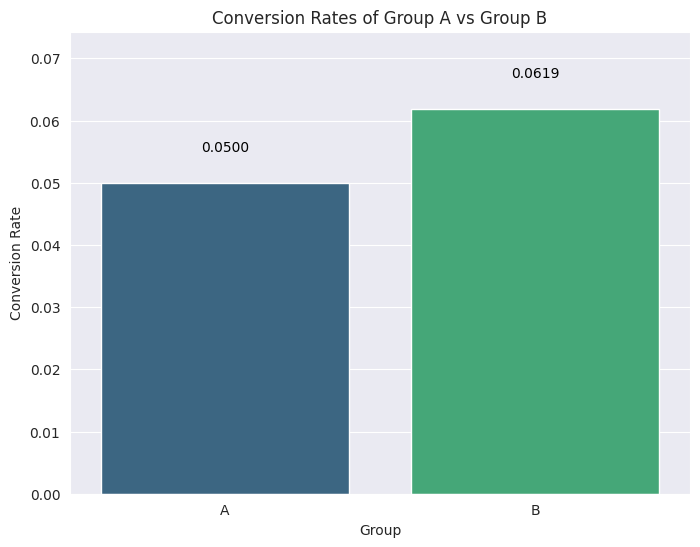

In [46]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Group', y='Conversion_Rate', data=df_ab, palette='viridis')
plt.title('Conversion Rates of Group A vs Group B')
plt.xlabel('Group')
plt.ylabel('Conversion Rate')
plt.ylim(0, max(df_ab['Conversion_Rate']) * 1.2)

for index, row in df_ab.iterrows():
    plt.text(index, row['Conversion_Rate'] + 0.005, f'{row['Conversion_Rate']:.4f}', color='black', ha="center")

plt.show()

### 9.6 Kesimpulan

Berdasarkan A/B test, kita dapat menyimpulkan apakah desain baru (Grup B) berkinerja secara signifikan lebih baik daripada desain lama (Grup A) atau apakah perbedaan yang diamati kemungkinan besar disebabkan oleh peluang acak. Interpretasi tergantung pada apakah nilai p lebih kecil dari tingkat signifikansi yang dipilih (alpha).

### Insight dari Implementasi A/B Testing

Implementasi A/B Testing yang telah dilakukan memberikan pemahaman penting tentang perbandingan kinerja antara dua variasi (Grup A dan Grup B) berdasarkan metrik tingkat konversi. Berikut adalah ringkasan dan implikasi dari hasil pengujian:

1.  **Tingkat Konversi yang Diamati**: Berdasarkan data sampel, Grup A memiliki tingkat konversi sebesar 5.00% (50 konversi dari 1000 pengunjung), sedangkan Grup B menunjukkan tingkat konversi yang lebih tinggi yaitu 6.19% (65 konversi dari 1050 pengunjung). Secara numerik, Grup B memang terlihat memiliki kinerja yang lebih baik.

2.  **Hasil Uji Hipotesis (Z-test)**:
    *   **Hipotesis Nol (H0)**: Tidak ada perbedaan signifikan antara tingkat konversi Grup A dan Grup B.
    *   **Hipotesis Alternatif (H1)**: Ada perbedaan signifikan antara tingkat konversi Grup A dan Grup B.
    *   **Nilai P (p-value)**: Hasil Z-test menunjukkan nilai p sebesar **0.2417**.
    *   **Tingkat Signifikansi (alpha)**: Tingkat signifikansi yang ditetapkan adalah **0.05**.

3.  **Kesimpulan Statistik**: Karena nilai p (0.2417) **lebih besar** dari tingkat signifikansi (0.05), kita **gagal menolak hipotesis nol**. Ini berarti, meskipun ada perbedaan tingkat konversi yang terlihat secara kasat mata antara Grup A dan Grup B, perbedaan tersebut **tidak signifikan secara statistik**. Dengan kata lain, perbedaan 1.19% dalam tingkat konversi yang diamati kemungkinan besar hanya terjadi karena kebetulan acak, bukan karena salah satu desain (Grup B) secara fundamental lebih baik dari yang lain.

4.  **Implikasi untuk Pengambilan Keputusan**: Berdasarkan hasil A/B test ini, tidak ada bukti statistik yang cukup kuat untuk menyatakan bahwa desain Grup B secara signifikan lebih unggul dari Grup A dalam hal tingkat konversi. Oleh karena itu, keputusan untuk mengimplementasikan Grup B sebagai desain yang "lebih baik" tidak dapat didukung secara statistik dengan data yang ada. Jika tujuan adalah untuk menemukan desain yang benar-benar meningkatkan konversi, mungkin diperlukan:
    *   **Pengumpulan Data Lebih Lanjut**: Meningkatkan ukuran sampel (jumlah pengunjung) untuk kedua grup dapat memberikan kekuatan statistik yang lebih tinggi untuk mendeteksi perbedaan yang lebih kecil jika memang ada.
    *   **Re-evaluasi Desain**: Desain Grup B mungkin perlu dipertimbangkan ulang atau diiterasi lebih lanjut jika tujuannya adalah peningkatan yang signifikan.

Secara keseluruhan, A/B testing ini menunjukkan pentingnya pendekatan berbasis data. Meskipun ada perbedaan numerik, tanpa signifikansi statistik, kita tidak bisa dengan yakin menyimpulkan adanya efek nyata dari perubahan yang diuji.